# Análisis de cuentas a pagar: Maya y Bávaro

Este notebook recoge la ejecución completa del pipeline analítico aplicado a las UEs de Maya y Bávaro, incluyendo:
- anonimización,
- preprocesado,
- casuística,
- anticipos,
- clasificación semántica,
- detección de duplicados y anomalías,
- riesgo global,
- clustering,
- modelos supervisados,
- análisis comparativo,
- análisis temporal y forecasting.

In [1]:
import pandas as pd
import numpy as np
import os, re, joblib, warnings, unicodedata, math, contextlib,io
from functions import fbl1n, preprocess, casuistica,anticipos_proveedores, excel
from ml import (propagar_solicitud_proveedor, case_score, zero_shot, detectar_duplicados, anomalias_isolation, riesgo_global, global_stats, cluster_kmeans, 
                rf_regressor, rf_classifier,
                proveedor_kpis, analisis_UE, clustering_proveedores, pca_clustering_proveedores, flatten_df, run_pipeline, excel_ml,
                extremos_anuales, preparar_serie_ts, modelo_ets, modelo_prophet, modelo_sarimax_auto, entrenar_modelo, evaluar_forecast, pipeline_forecast,pipeline_forecast_general,forecast_batch, plot_panel_train_test_pred)

from typing import Dict
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import IsolationForest, RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score, mean_absolute_error, r2_score, f1_score, confusion_matrix, mean_squared_error
from sklearn.decomposition import PCA
import joblib
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from treeinterpreter import treeinterpreter as ti
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm
import matplotlib.dates as mdates
from urllib3.exceptions import InsecureRequestWarning
warnings.filterwarnings("ignore", category=InsecureRequestWarning)
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from openpyxl.utils import get_column_letter
from openpyxl.styles import PatternFill, Font, Alignment

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
)


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def describe_df(df, name="df"):
    return pd.DataFrame([{
        "dataset": name,
        "filas": len(df),
        "columnas": df.shape[1],
        "nulos_totales": int(df.isna().sum().sum())
    }])


c:\Users\IrenePalomaresCastro\Downloads\SAIH_IMPORT_analisis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1. FUNCIÓN AUXILIAR: normalizar cuenta

def normalizar_cuenta(valor):
    """
    Normaliza la cuenta para que el mismo proveedor tenga siempre
    la misma clave aunque venga como int, float, string, con espacios, etc.
    """
    if pd.isna(valor):
        return pd.NA

    s = str(valor).strip()

    # Si viene como '50000.0' -> '50000'
    if s.endswith(".0"):
        s = s[:-2]

    # Si es numérico puro, quitar ceros a la izquierda SOLO si te interesa
    # OJO: si en tu negocio los ceros a la izquierda son significativos,
    # elimina este bloque
    if s.isdigit():
        s = str(int(s))

    return s


# 2. CONSTRUIR MAPA ÚNICO DE PROVEEDORES

def construir_mapa_proveedores(*dfs):
    """
    Construye un único mapa de anonimización a partir de varios DataFrames.
    Usa Cuenta normalizada como clave maestra.
    """
    cuentas = pd.concat(
        [df["Cuenta"] for df in dfs if "Cuenta" in df.columns],
        ignore_index=True
    )

    cuentas_norm = (
        cuentas.map(normalizar_cuenta)
               .dropna()
               .drop_duplicates()
               .tolist()
    )

    mapa = {
        cuenta: f"Prov_{i:04d}"
        for i, cuenta in enumerate(cuentas_norm, start=1)
    }

    return mapa


# 3. APLICAR MAPA DE ANONIMIZACIÓN

def anonimizar_con_mapa(df, mapa_proveedores):
    """
    Aplica el mismo alias a Cuenta y Nombre1 usando Cuenta normalizada
    como clave maestra.
    """
    df = df.copy()

    cuenta_norm = df["Cuenta"].map(normalizar_cuenta)

    # Alias único por proveedor
    alias = cuenta_norm.map(mapa_proveedores)

    # Sustituir ambas columnas con el mismo alias
    df["Cuenta"] = alias
    df["Nombre1"] = alias

    # Restaurar nulos si la cuenta original era nula
    df.loc[cuenta_norm.isna(), ["Cuenta", "Nombre1"]] = pd.NA

    return df

In [3]:
"""sociedades_maya = ["5600","5601","5602","5603","5604","6300","7000","P300","5606"]
fechas_maya = ["19-06-2023","05-05-2024", "08-06-2025" ]

data = [
    ("PAG_MASTER", "3", "1", fecha, fecha, sociedad)
    for fecha in fechas_maya
    for sociedad in sociedades_maya
]

df_maya = fbl1n(data=data, carpeta="Maya", base_dir=".")

sociedades_bavaro = ["7400", "7401","7601","7800","7801","J400","7402"]
fechas_bavaro = ["19-06-2023","05-11-2024", "027-10-2025" ]

data = [
    ("PAG_MASTER", "3", "1", fecha, fecha, sociedad)
    for fecha in fechas_bavaro
    for sociedad in sociedades_bavaro
]

df_bavaro = fbl1n(data=data, carpeta="Bavaro", base_dir=".")"""

df_maya = pd.concat( [ pd.read_csv('Datos_Bavaro_Maya/Maya_2023.csv'),  pd.read_csv('Datos_Bavaro_Maya/Maya_2024.csv'), pd.read_csv('Datos_Bavaro_Maya/Maya_2025.csv')], ignore_index = True)
df_bavaro = pd.concat( [ pd.read_csv('Datos_Bavaro_Maya/Bavaro_2023.csv'),  pd.read_csv('Datos_Bavaro_Maya/Bavaro_2024.csv'), pd.read_csv('Datos_Bavaro_Maya/Bavaro_2025.csv')], ignore_index = True)

In [4]:
# 1. ANONIMIZACIÓN COMÚN DE PROVEEDORES

# Construir un único mapa de proveedores para ambas UEs
mapa = construir_mapa_proveedores(df_maya, df_bavaro)

# Aplicar anonimización con el mismo mapa
df_maya_anonim = anonimizar_con_mapa(df_maya, mapa)
df_bavaro_anonim = anonimizar_con_mapa(df_bavaro, mapa)


In [5]:
# 2. INSPECCIÓN INICIAL DE LOS DATASETS


print("UE: MAYA - INFORMACIÓN INICIAL")
print("Dimensión Maya:", df_maya_anonim.shape)
display(df_maya_anonim.head())
display(df_maya_anonim.describe(include="all"))


print("\n" + "-" * 100 + "\n")

print("UE: BÁVARO - INFORMACIÓN INICIAL")
print("Dimensión Bávaro:", df_bavaro_anonim.shape)
display(df_bavaro_anonim.head())
display(df_bavaro_anonim.describe(include="all"))

UE: MAYA - INFORMACIÓN INICIAL
Dimensión Maya: (28729, 69)


,Unnamed: 0,CodHotel_Auditoria,ID_PETICION,ID_ETL,ID_Ejecucion,FyH_Ejecucion,Act_fijo,Doc_comp,Compens,Clase,...,Nombre1,PARAM_FechaClave,CLASI_Clasificacion,Asignacion,Fe_contab2,Fecha_pago2,Fecha_doc2,Venc_Neto2,Registrado2,Fecha_informe
0,0,NaN,NaN,NaN,NaN,NaN,NaN,188430890.0,2023-11-27,RE,...,Prov_0001,NaN,[NO CLASIFICADO],NaN,2022-01-11,2022-02-20,2022-01-11,2022-02-20,2022-01-11,2023-06-19
1,1,NaN,NaN,NaN,NaN,NaN,NaN,188336573.0,2024-08-01,RE,...,Prov_0002,NaN,[NO CLASIFICADO],NaN,2023-01-12,2023-01-31,2023-01-12,2023-01-31,2023-01-12,2023-06-19
2,2,NaN,NaN,NaN,NaN,NaN,NaN,188227003.0,2023-06-27,RE,...,Prov_0003,NaN,[NO CLASIFICADO],NaN,2023-01-13,2023-01-13,2023-01-13,2023-01-13,2023-01-14,2023-06-19
3,3,NaN,NaN,NaN,NaN,NaN,NaN,188201248.0,2025-05-01,RE,...,Prov_0004,NaN,[NO CLASIFICADO],NaN,2021-02-18,2021-03-16,2021-02-18,2021-03-16,2021-02-18,2023-06-19
4,4,NaN,NaN,NaN,NaN,NaN,NaN,101248193.0,2024-06-18,KR,...,Prov_0005,NaN,[NO CLASIFICADO],NaN,2023-01-17,2023-02-24,2023-01-10,2023-02-24,2023-01-17,2023-06-19


,Unnamed: 0,CodHotel_Auditoria,ID_PETICION,ID_ETL,ID_Ejecucion,FyH_Ejecucion,Act_fijo,Doc_comp,Compens,Clase,...,Nombre1,PARAM_FechaClave,CLASI_Clasificacion,Asignacion,Fe_contab2,Fecha_pago2,Fecha_doc2,Venc_Neto2,Registrado2,Fecha_informe
count,28729.000000,0.0,0.0,0.0,0.0,0.0,9.000000,2.865100e+04,28729,28729,...,28729,0.0,28729,0.0,28729,26958,28729,28729,28729,28729
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,253,13,...,947,NaN,1,NaN,614,694,655,701,578,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-06-27,RE,...,Prov_0188,NaN,[NO CLASIFICADO],NaN,2024-04-30,2023-06-20,2024-04-30,2023-06-20,2024-05-01,2023-06-19
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4976,22346,...,1573,NaN,28729,NaN,872,1663,809,1663,786,9813
mean,4790.986286,NaN,NaN,NaN,NaN,NaN,11426.777778,2.067997e+08,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,2770.180783,NaN,NaN,NaN,NaN,NaN,1019.647829,1.157187e+08,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN,NaN,10180.000000,1.000415e+06,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2394.000000,NaN,NaN,NaN,NaN,NaN,10667.000000,1.012592e+08,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,4788.000000,NaN,NaN,NaN,NaN,NaN,10725.000000,1.885125e+08,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,7182.000000,NaN,NaN,NaN,NaN,NaN,12453.000000,3.010887e+08,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



----------------------------------------------------------------------------------------------------

UE: BÁVARO - INFORMACIÓN INICIAL
Dimensión Bávaro: (14086, 69)


,Unnamed: 0,CodHotel_Auditoria,ID_PETICION,ID_ETL,ID_Ejecucion,FyH_Ejecucion,Act_fijo,Doc_comp,Compens,Clase,...,Nombre1,PARAM_FechaClave,CLASI_Clasificacion,Asignacion,Fe_contab2,Fecha_pago2,Fecha_doc2,Venc_Neto2,Registrado2,Fecha_informe
0,0,NaN,NaN,NaN,NaN,NaN,NaN,88244987,2023-09-27,SA,...,Prov_0948,NaN,[NO CLASIFICADO],NaN,2023-09-05,2023-09-05,2023-09-05,2023-09-05,2023-09-07,2023-06-19
1,1,NaN,NaN,NaN,NaN,NaN,NaN,88244984,2023-09-27,SA,...,Prov_0948,NaN,[NO CLASIFICADO],NaN,2023-09-04,2023-09-04,2023-09-04,2023-09-04,2023-09-06,2023-06-19
2,2,NaN,NaN,NaN,NaN,NaN,NaN,88247835,2023-09-30,SA,...,Prov_0948,NaN,[NO CLASIFICADO],NaN,2023-09-03,2023-09-03,2023-09-03,2023-09-03,2023-09-04,2023-06-19
3,3,NaN,NaN,NaN,NaN,NaN,NaN,88244986,2023-09-27,SA,...,Prov_0948,NaN,[NO CLASIFICADO],NaN,2023-09-05,2023-09-05,2023-09-05,2023-09-05,2023-09-06,2023-06-19
4,4,NaN,NaN,NaN,NaN,NaN,NaN,88244986,2023-09-27,SA,...,Prov_0948,NaN,[NO CLASIFICADO],NaN,2023-09-06,2023-09-06,2023-09-06,2023-09-06,2023-09-07,2023-06-19


,Unnamed: 0,CodHotel_Auditoria,ID_PETICION,ID_ETL,ID_Ejecucion,FyH_Ejecucion,Act_fijo,Doc_comp,Compens,Clase,...,Nombre1,PARAM_FechaClave,CLASI_Clasificacion,Asignacion,Fe_contab2,Fecha_pago2,Fecha_doc2,Venc_Neto2,Registrado2,Fecha_informe
count,14086.000000,0.0,0.0,0.0,0.0,0.0,14.000000,1.408600e+04,14086,14086,...,14086,0.0,14086,0.0,14086,9864,14086,14086,14086,14086
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,128,10,...,677,NaN,1,NaN,385,374,434,536,386,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-20,RE,...,Prov_0017,NaN,[NO CLASIFICADO],NaN,2024-10-31,2024-11-30,2023-08-01,2024-11-30,2024-10-01,2023-06-19
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1173,11837,...,1160,NaN,14086,NaN,507,302,219,302,425,5153
mean,2362.989919,NaN,NaN,NaN,NaN,NaN,30310.857143,1.034665e+07,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1382.361735,NaN,NaN,NaN,NaN,NaN,188.543346,2.868809e+07,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN,NaN,29988.000000,1.000360e+06,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1173.250000,NaN,NaN,NaN,NaN,NaN,30135.500000,1.206852e+06,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2347.000000,NaN,NaN,NaN,NaN,NaN,30373.000000,1.401000e+06,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,3521.000000,NaN,NaN,NaN,NaN,NaN,30488.000000,1.470644e+06,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# 3. PREPROCESS

print("UE: MAYA - PREPROCESS")
df_m_pre = preprocess(df_maya_anonim)
print("Dimensión tras preprocess:", df_m_pre.shape)
display(df_m_pre.head())

print("\n" + "-" * 100)
print("\n")

print("UE: BÁVARO - PREPROCESS")
df_b_pre = preprocess(df_bavaro_anonim)
print("Dimensión tras preprocess:", df_b_pre.shape)
display(df_b_pre.head())

UE: MAYA - PREPROCESS
Dimensión tras preprocess: (32455, 50)


,UE,Act_fijo,N_doc,Compens,Clase,Fecha_doc,CT,Fe_contab,Sociedad,ImpteML2,...,Fe_contab2,Fecha_pago2,Fecha_doc2,Venc_Neto2,Registrado2,Fecha Clave,Antigüedad,Delta_fecha_doc,_is_total,antig
0,Maya,NaN,188430890.0,2023-11-27,RE,2020-03-24 00:00:00,31,2020-03-24 00:00:00,5601,-84.32,...,2020-03-24,2020-04-20,2020-03-24,2020-04-20,2020-03-24,2023-06-19,1182,0,0,365
1,Maya,NaN,188430890.0,2023-11-27,RE,2020-04-07 00:00:00,31,2020-04-07 00:00:00,5601,-88.88,...,2020-04-07,2020-05-20,2020-04-07,2020-05-20,2020-04-07,2023-06-19,1168,0,0,365
2,Maya,NaN,188430890.0,2023-11-27,RE,2021-08-11 00:00:00,31,2021-08-11 00:00:00,5601,-211.9,...,2021-08-11,2021-09-20,2021-08-11,2021-09-20,2021-08-11,2023-06-19,677,0,0,365
3,Maya,NaN,188430890.0,2023-11-27,RE,2021-08-11 00:00:00,31,2021-08-11 00:00:00,5601,-19.15,...,2021-08-11,2021-09-20,2021-08-11,2021-09-20,2021-08-11,2023-06-19,677,0,0,365
4,Maya,NaN,188430890.0,2023-11-27,RE,2021-08-11 00:00:00,31,2021-08-11 00:00:00,5601,-155.18,...,2021-08-11,2021-09-20,2021-08-11,2021-09-20,2021-08-11,2023-06-19,677,0,0,365



----------------------------------------------------------------------------------------------------


UE: BÁVARO - PREPROCESS
Dimensión tras preprocess: (16231, 51)


,UE,Act_fijo,N_doc,Compens,Clase,Fecha_doc,CT,Fe_contab,Sociedad,ImpteML2,...,Fe_contab2,Fecha_pago2,Fecha_doc2,Venc_Neto2,Registrado2,Fecha Clave,Antigüedad,Delta_fecha_doc,_is_total,antig
0,Bavaro,NaN,88259872,2023-10-12,SA,2023-01-09 00:00:00,34,2023-01-09 00:00:00,7400,-22.0,...,2023-01-09,2023-01-09,2023-01-09,2023-01-09,2023-01-09,2023-06-19,161,0,0,180
1,Bavaro,NaN,88259872,2023-10-12,SA,2023-01-09 00:00:00,34,2023-01-09 00:00:00,7400,-44.71,...,2023-01-09,2023-01-09,2023-01-09,2023-01-09,2023-01-09,2023-06-19,161,0,0,180
2,Bavaro,NaN,88259320,2023-10-11,SA,2023-01-10 00:00:00,34,2023-01-10 00:00:00,7400,-44.26,...,2023-01-10,2023-01-10,2023-01-10,2023-01-10,2023-01-10,2023-06-19,160,0,0,180
3,Bavaro,NaN,88259320,2023-10-11,SA,2023-01-10 00:00:00,34,2023-01-10 00:00:00,7400,-44.26,...,2023-01-10,2023-01-10,2023-01-10,2023-01-10,2023-01-10,2023-06-19,160,0,0,180
4,Bavaro,NaN,88259321,2023-10-11,SA,2023-01-10 00:00:00,34,2023-01-10 00:00:00,7400,-31.24,...,2023-01-10,2023-01-10,2023-01-10,2023-01-10,2023-01-10,2023-06-19,160,0,0,180


CASUÍSTICA

Casuística Maya


Casuística
Acreedora               25348
<NA>                     3727
Deudora                  3045
Acreedora antigua         319
Anticipo / Retención       16
Name: count, dtype: int64


Casuística Bávaro


Casuística
Acreedora               12964
<NA>                     2145
Deudora                  1081
Anticipo / Retención       26
Acreedora antigua          15
Name: count, dtype: int64

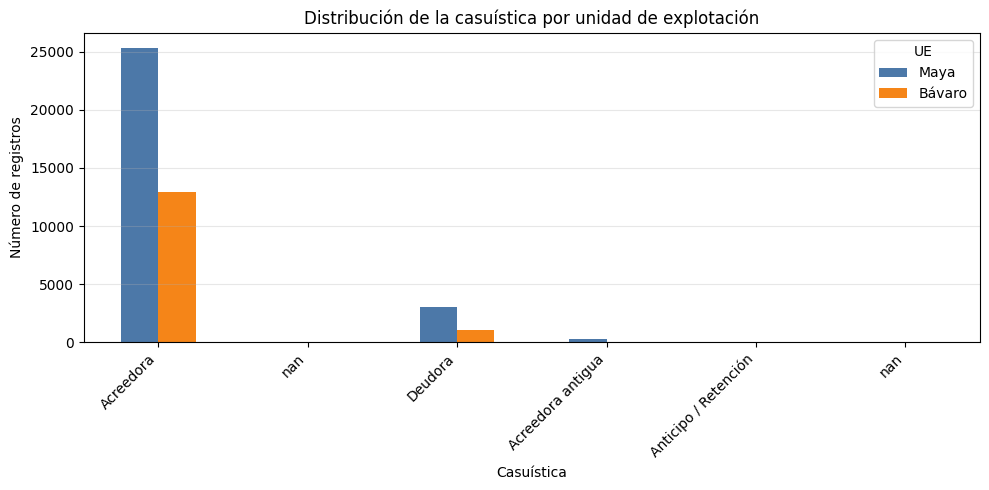

In [7]:
# 4. CASUÍSTICA CONTABLE

print("CASUÍSTICA")
df_m_casos = casuistica(df_m_pre)
df_b_casos = casuistica(df_b_pre)

print("\nCasuística Maya")
display(df_m_casos["Casuística"].value_counts(dropna=False))

print("\nCasuística Bávaro")
display(df_b_casos["Casuística"].value_counts(dropna=False))

cas_m = df_m_casos["Casuística"].value_counts(dropna=False).rename("Maya")
cas_b = df_b_casos["Casuística"].value_counts(dropna=False).rename("Bávaro")

df_fig_71 = pd.concat([cas_m, cas_b], axis=1).fillna(0)
df_fig_71.index = df_fig_71.index.astype(str)

ax = df_fig_71.plot(
    kind="bar",
    figsize=(10, 5),
    color=["#4C78A8", "#F58518"]
)

plt.title("Distribución de la casuística por unidad de explotación")
plt.xlabel("Casuística")
plt.ylabel("Número de registros")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="UE")
plt.tight_layout()
plt.show()


ANÁLISIS

Análisis Maya


Análisis
Ok                                    27192
Ok saldo total acreedor                3621
Deudora Antigua                        1066
Acreedora antigua                       319
Ok abono reciente                        76
Saldo total deudor                       71
Revisar Z6 (finiquitos/reembolsos)       60
Ok saldado                               34
                                         16
Name: count, dtype: int64


Análisis Bávaro


Análisis
Ok                                    13532
Ok saldo total acreedor                2084
Deudora Antigua                         489
Saldo total deudor                       47
                                         26
Ok abono reciente                        19
Acreedora antigua                        15
Ok saldado                               14
Revisar Z6 (finiquitos/reembolsos)        5
Name: count, dtype: int64

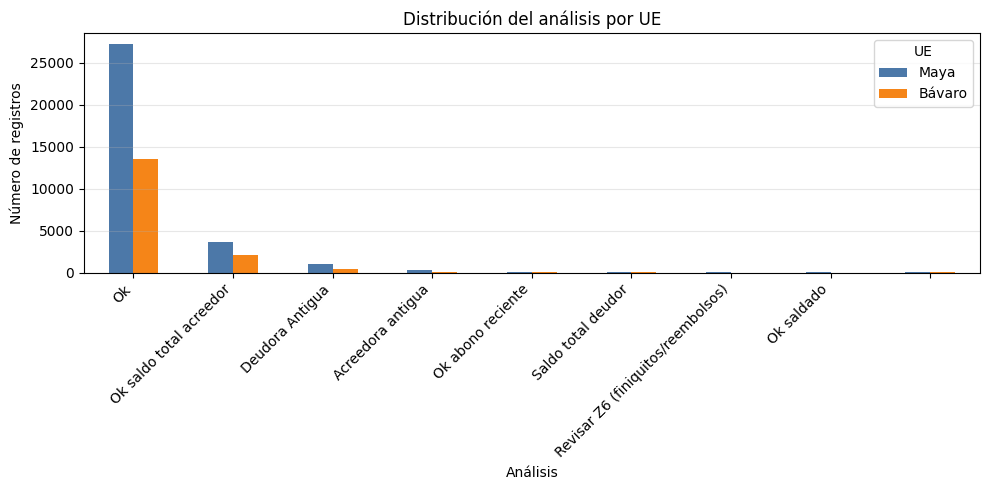

In [8]:
print("ANÁLISIS")

print("\nAnálisis Maya")
display(df_m_casos["Análisis"].value_counts(dropna=False))

print("\nAnálisis Bávaro")
display(df_b_casos["Análisis"].value_counts(dropna=False))


cas_m = df_m_casos["Análisis"].value_counts(dropna=False).rename("Maya")
cas_b = df_b_casos["Análisis"].value_counts(dropna=False).rename("Bávaro")

df_fig_71 = pd.concat([cas_m, cas_b], axis=1).fillna(0)
df_fig_71.index = df_fig_71.index.astype(str)

ax = df_fig_71.plot(
    kind="bar",
    figsize=(10, 5),
    color=["#4C78A8", "#F58518"]
)

plt.title("Distribución del análisis por UE")
plt.xlabel("Análisis")
plt.ylabel("Número de registros")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="UE")
plt.tight_layout()
plt.show()



SOLICITUDES

Solicitudes Maya


Solicitud
<NA>                                                                                                                                                                                                                           31849
Revisar partidas deudoras                                                                                                                                                                                                        367
Acreedoras antiguas sin pagos identificados: confirmar si se pagará o procede ajuste a ingreso.                                                                                                                                  154
Saldo total deudor con partidas deudoras antiguas: solicitar compensación.                                                                                                                                                        21
Saldo total saldado; no obstante, existen partidas a revisar. Saldo total 


Solicitudes Bávaro


Solicitud
<NA>                                                                                                                                                                                                                16016
Revisar partidas deudoras                                                                                                                                                                                             185
Saldo total saldado; no obstante, existen partidas a revisar. Saldo total saldado; no obstante, existen partidas a revisar. Revisar partidas deudoras                                                                  13
Saldo deudor con partidas deudoras y acreedoras: solicitar compensación.                                                                                                                                                8
Existen partidas con clase Z6: revisar compensación/soporte y confirmar tratamiento.                                  

C:\Users\IrenePalomaresCastro\AppData\Local\Temp\ipykernel_1296\1847618207.py:29: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


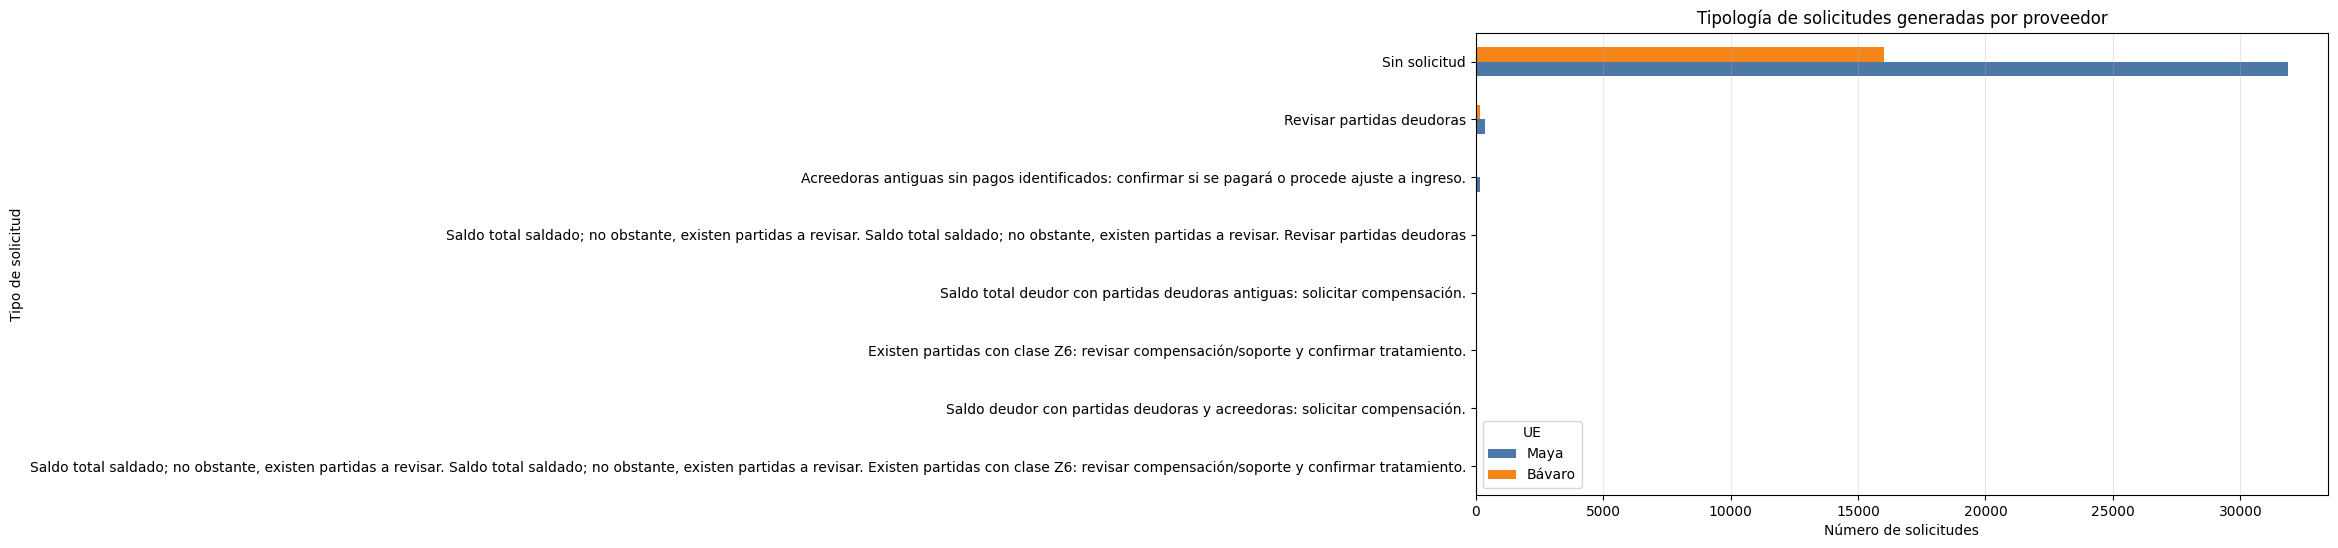

In [9]:
print("SOLICITUDES")

print("\nSolicitudes Maya")
display(df_m_casos["Solicitud"].value_counts(dropna=False))

print("\nSolicitudes Bávaro")
display(df_b_casos["Solicitud"].value_counts(dropna=False))


sol_m = df_m_casos["Solicitud"].fillna("Sin solicitud").value_counts().rename("Maya")
sol_b = df_b_casos["Solicitud"].fillna("Sin solicitud").value_counts().rename("Bávaro")

df_fig_73 = pd.concat([sol_m, sol_b], axis=1).fillna(0)

df_fig_73["Total"] = df_fig_73.sum(axis=1)
df_fig_73 = df_fig_73.sort_values("Total", ascending=True).drop(columns="Total").tail(8)

ax = df_fig_73.plot(
    kind="barh",
    figsize=(11, 6),
    color=["#4C78A8", "#F58518"]
)

plt.title("Tipología de solicitudes generadas por proveedor")
plt.xlabel("Número de solicitudes")
plt.ylabel("Tipo de solicitud")
plt.grid(axis="x", alpha=0.3)
plt.legend(title="UE")
plt.tight_layout()
plt.show()




UE: MAYA - ANTICIPOS
16 partidas detectadas como anticipos (407)
0 partidas detectadas como retenciones (40010001)
Etiquetas de anticipos Maya


Etiqueta
Anticipos a proveedores         16
TOTAL proveedor (saldo real)     5
Name: count, dtype: int64


Análisis anticipos Maya


Análisis
Anticipo fuera de plazo (según vencimiento SAP)    16
<NA>                                                5
Name: count, dtype: int64


Solicitudes anticipos Maya


...

Etiqueta
Anticipos a proveedores         26
TOTAL proveedor (saldo real)    13
Name: count, dtype: int64


Análisis anticipos Bávaro


Análisis
Anticipo fuera de plazo (según vencimiento SAP)           20
<NA>                                                      13
Anticipo (sin indicador objetivo de incidencia en SAP)     6
Name: count, dtype: int64


Solicitudes anticipos Bávaro


Solicitud
Revisar: vencimiento en SAP anterior a la Fecha del informe. Confirmar que el anticipo sigue en plazo según contrato/pedido y que el bien/servicio continúa pendiente de recibir. Aportar contrato/pedido, autorización del pago y soporte de seguimiento.    20
<NA>                                                                                                                                                                                                                                                          13
Sin indicador objetivo de incidencia en SAP. Requiere verificación documental (contrato/pedido, autorización, bien/servicio pendiente) y plan/fecha de compensación/regularización.                                                                            6
Name: count, dtype: int64

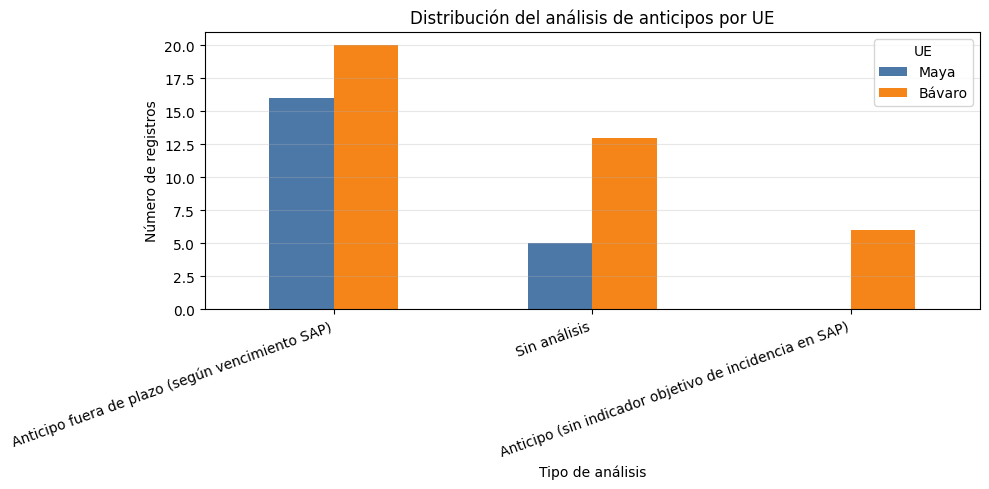

In [10]:

# 5. ANTICIPOS Y RETENCIONES

print("UE: MAYA - ANTICIPOS")
df_m_ant = anticipos_proveedores(df_m_pre)

print("Etiquetas de anticipos Maya")
display(df_m_ant["Etiqueta"].value_counts(dropna=False))

print("\nAnálisis anticipos Maya")
display(df_m_ant["Análisis"].value_counts(dropna=False))

print("\nSolicitudes anticipos Maya")
display(df_m_ant["Solicitud"].value_counts(dropna=False))

print("\n" + "-" * 100)
print("\n")

print("UE: BÁVARO - ANTICIPOS")
df_b_ant = anticipos_proveedores(df_b_pre)

print("Etiquetas de anticipos Bávaro")
display(df_b_ant["Etiqueta"].value_counts(dropna=False))

print("\nAnálisis anticipos Bávaro")
display(df_b_ant["Análisis"].value_counts(dropna=False))

print("\nSolicitudes anticipos Bávaro")
display(df_b_ant["Solicitud"].value_counts(dropna=False))


ant_m = df_m_ant["Análisis"].fillna("Sin análisis").value_counts().rename("Maya")
ant_b = df_b_ant["Análisis"].fillna("Sin análisis").value_counts().rename("Bávaro")

df_fig_74 = pd.concat([ant_m, ant_b], axis=1).fillna(0)

ax = df_fig_74.plot(
    kind="bar",
    figsize=(10, 5),
    color=["#4C78A8", "#F58518"]
)

plt.title("Distribución del análisis de anticipos por UE")
plt.xlabel("Tipo de análisis")
plt.ylabel("Número de registros")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="UE")
plt.tight_layout()
plt.show()

In [11]:
# 6. GENERACIÓN DE EXCEL

excel(df_maya_anonim, "Excel_Maya.xlsx")
print("Excel Maya generado")

excel(df_bavaro_anonim, "Excel_Bavaro.xlsx")
print("Excel Bávaro generado")

16 partidas detectadas como anticipos (407)
0 partidas detectadas como retenciones (40010001)


c:\Users\IrenePalomaresCastro\Downloads\SAIH_IMPORT_analisis\TFG\functions.py:914: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_sol[c] = pd.to_datetime(df_sol[c], errors="coerce").dt.date


Excel Maya generado
26 partidas detectadas como anticipos (407)
0 partidas detectadas como retenciones (40010001)


c:\Users\IrenePalomaresCastro\Downloads\SAIH_IMPORT_analisis\TFG\functions.py:914: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_sol[c] = pd.to_datetime(df_sol[c], errors="coerce").dt.date


Excel Bávaro generado


In [12]:
# CELDA 1. PROPAGACIÓN DE SOLICITUD + CASE_SCORE

# -------------------------
# MAYA
# -------------------------
print("MAYA - Propagación de solicitud + CASE_SCORE")

df_m_base = propagar_solicitud_proveedor(df_m_casos)
df_m_base = case_score(df_m_base)

print("Dimensión Maya:", df_m_base.shape)
display(df_m_base.head())

# -------------------------
# BÁVARO
# -------------------------
print("\n" + "-" * 100)
print("\n")

print("BÁVARO - Propagación de solicitud + CASE_SCORE")

df_b_base = propagar_solicitud_proveedor(df_b_casos)
df_b_base = case_score(df_b_base)

print("Dimensión Bávaro:", df_b_base.shape)
display(df_b_base.head())

MAYA - Propagación de solicitud + CASE_SCORE
Dimensión Maya: (32455, 29)


,Fecha Clave,UE,Sociedad,Cuenta,Nombre1,N_doc,Registrado,Ej_mes,Fe_contab,Venc_neto,...,BP,CPag,Fecha_pago,LibrMay,antig,_is_total,Casuística,Análisis,Solicitud,CASE_SCORE
0,2023-06-19,Maya,5601,Prov_0001,Prov_0001,188430890.0,2020-03-24 00:00:00,3,2020-03-24 00:00:00,2020-04-20 00:00:00,...,NaN,MCCM,2020-04-20,40000001,365,0,Acreedora antigua,Acreedora antigua,<NA>,0.75
1,2023-06-19,Maya,5601,Prov_0001,Prov_0001,188430890.0,2020-04-07 00:00:00,4,2020-04-07 00:00:00,2020-05-20 00:00:00,...,NaN,MCCM,2020-05-20,40000001,365,0,Acreedora antigua,Acreedora antigua,<NA>,0.75
2,2023-06-19,Maya,5601,Prov_0001,Prov_0001,188430890.0,2021-08-11 00:00:00,8,2021-08-11 00:00:00,2021-09-20 00:00:00,...,NaN,MCCM,2021-09-20,40000001,365,0,Acreedora antigua,Acreedora antigua,<NA>,0.75
3,2023-06-19,Maya,5601,Prov_0001,Prov_0001,188430890.0,2021-08-11 00:00:00,8,2021-08-11 00:00:00,2021-09-20 00:00:00,...,NaN,MCCM,2021-09-20,40000001,365,0,Acreedora antigua,Acreedora antigua,<NA>,0.75
4,2023-06-19,Maya,5601,Prov_0001,Prov_0001,188430890.0,2021-08-11 00:00:00,8,2021-08-11 00:00:00,2021-09-20 00:00:00,...,NaN,MCCM,2021-09-20,40000001,365,0,Acreedora antigua,Acreedora antigua,<NA>,0.75



----------------------------------------------------------------------------------------------------


BÁVARO - Propagación de solicitud + CASE_SCORE
Dimensión Bávaro: (16231, 29)


,Fecha Clave,UE,Sociedad,Cuenta,Nombre1,N_doc,Registrado,Ej_mes,Fe_contab,Venc_neto,...,BP,CPag,Fecha_pago,LibrMay,antig,_is_total,Casuística,Análisis,Solicitud,CASE_SCORE
0,2023-06-19,Bavaro,7400,Prov_0017,Prov_0017,88259872,2023-01-09 00:00:00,1,2023-01-09 00:00:00,2023-01-09 00:00:00,...,NaN,NaN,2023-01-09,40000001,180,0,Acreedora,Ok,<NA>,0.35
1,2023-06-19,Bavaro,7400,Prov_0017,Prov_0017,88259872,2023-01-09 00:00:00,1,2023-01-09 00:00:00,2023-01-09 00:00:00,...,NaN,NaN,2023-01-09,40000001,180,0,Acreedora,Ok,<NA>,0.35
2,2023-06-19,Bavaro,7400,Prov_0017,Prov_0017,88259320,2023-01-10 00:00:00,1,2023-01-10 00:00:00,2023-01-10 00:00:00,...,NaN,NaN,2023-01-10,40000001,180,0,Acreedora,Ok,<NA>,0.35
3,2023-06-19,Bavaro,7400,Prov_0017,Prov_0017,88259320,2023-01-10 00:00:00,1,2023-01-10 00:00:00,2023-01-10 00:00:00,...,NaN,NaN,2023-01-10,40000001,180,0,Acreedora,Ok,<NA>,0.35
4,2023-06-19,Bavaro,7400,Prov_0017,Prov_0017,88259321,2023-01-10 00:00:00,1,2023-01-10 00:00:00,2023-01-10 00:00:00,...,NaN,NaN,2023-01-10,40000001,180,0,Acreedora,Ok,<NA>,0.35


MAYA - Zero-Shot
Distribución de etiquetas Zero-Shot (Maya)


zs_label
Fecha fuera de periodo              17658
Términos de pago atípicos            4143
Proveedor sensible                   3884
Posible fraccionamiento de pagos     2968
Pago duplicado o similar             1183
Cambio de forma de pago              1121
Cumple normalidad                     608
Urgencia inusual                      571
Texto o referencia ambigua            319
Name: count, dtype: int64


----------------------------------------------------------------------------------------------------


BÁVARO - Zero-Shot
Distribución de etiquetas Zero-Shot (Bávaro)


zs_label
Fecha fuera de periodo              12787
Proveedor sensible                   1996
Posible fraccionamiento de pagos      689
Cambio de forma de pago               201
Términos de pago atípicos             164
Urgencia inusual                      137
Pago duplicado o similar              115
Texto o referencia ambigua             89
Cumple normalidad                      53
Name: count, dtype: int64

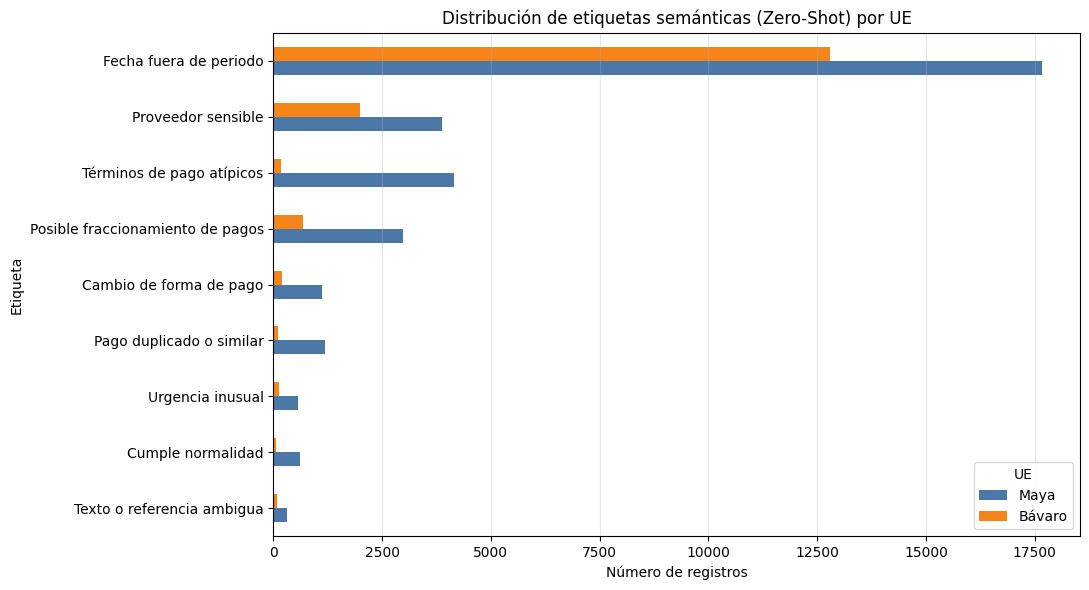

In [13]:
# CELDA 2. ZERO-SHOT

# -------------------------
# MAYA
# -------------------------

print("MAYA - Zero-Shot")
df_m_zs = zero_shot(df_m_base)

print("Distribución de etiquetas Zero-Shot (Maya)")
display(df_m_zs["zs_label"].value_counts(dropna=False))

# -------------------------
# BÁVARO
# -------------------------
print("\n" + "-" * 100)
print("\n")  

print("BÁVARO - Zero-Shot")
df_b_zs = zero_shot(df_b_base)

print("Distribución de etiquetas Zero-Shot (Bávaro)")
display(df_b_zs["zs_label"].value_counts(dropna=False))

# ============================================================
# FIGURA 7.5. DISTRIBUCIÓN DE ETIQUETAS ZERO-SHOT POR UE
# ============================================================

zs_m = df_m_zs["zs_label"].value_counts(dropna=False).rename("Maya")
zs_b = df_b_zs["zs_label"].value_counts(dropna=False).rename("Bávaro")

df_fig_75 = pd.concat([zs_m, zs_b], axis=1).fillna(0)

df_fig_75["Total"] = df_fig_75.sum(axis=1)
df_fig_75 = df_fig_75.sort_values("Total", ascending=True).drop(columns="Total")

ax = df_fig_75.plot(
    kind="barh",
    figsize=(11, 6),
    color=["#4C78A8", "#F58518"]
)

plt.title("Distribución de etiquetas semánticas (Zero-Shot) por UE")
plt.xlabel("Número de registros")
plt.ylabel("Etiqueta")
plt.grid(axis="x", alpha=0.3)
plt.legend(title="UE")
plt.tight_layout()
plt.show()

In [14]:
# CELDA 3. DETECCIÓN DE DUPLICADOS


# -------------------------
# MAYA
# -------------------------
print("MAYA - Detección de duplicados")
df_m_dup = detectar_duplicados(df_m_zs)

print("Distribución de duplicados (Maya)")
display(df_m_dup["Duplicado"].value_counts(dropna=False))

print("\nEjemplos de duplicados detectados (Maya)")
display(df_m_dup[df_m_dup["Duplicado"] == 1].head())

# -------------------------
# BÁVARO
# -------------------------
print("\n" + "-" * 100)
print("\n")

print("BÁVARO - Detección de duplicados")

df_b_dup = detectar_duplicados(df_b_zs)

print("Distribución de duplicados (Bávaro)")
display(df_b_dup["Duplicado"].value_counts(dropna=False))

print("\nEjemplos de duplicados detectados (Bávaro)")
display(df_b_dup[df_b_dup["Duplicado"] == 1].head())


MAYA - Detección de duplicados
Distribución de duplicados (Maya)


Duplicado
0    29305
1     3150
Name: count, dtype: int64


Ejemplos de duplicados detectados (Maya)


,Fecha Clave,UE,Sociedad,Cuenta,Nombre1,N_doc,Registrado,Ej_mes,Fe_contab,Venc_neto,...,antig,_is_total,Casuística,Análisis,Solicitud,CASE_SCORE,zs_label,zs_score,Duplicado_score,Duplicado
14,2023-06-19,Maya,5601,Prov_0002,Prov_0002,188336575.0,2022-11-29 00:00:00,11,2022-11-29 00:00:00,2022-11-30 00:00:00,...,365,0,Acreedora,Ok,<NA>,0.35,Urgencia inusual,0.030713,0.75,1
15,2023-06-19,Maya,5601,Prov_0002,Prov_0002,188336575.0,2022-12-21 00:00:00,12,2022-12-21 00:00:00,2022-12-31 00:00:00,...,365,0,Deudora,Deudora Antigua,<NA>,0.45,Términos de pago atípicos,0.004768,0.75,1
16,2023-06-19,Maya,5601,Prov_0002,Prov_0002,188336573.0,2023-01-12 00:00:00,1,2023-01-12 00:00:00,2023-01-31 00:00:00,...,365,0,Acreedora,Ok,<NA>,0.35,Urgencia inusual,0.032509,0.75,1
17,2023-06-19,Maya,5601,Prov_0002,Prov_0002,188336573.0,2023-02-17 00:00:00,2,2023-02-17 00:00:00,2023-02-28 00:00:00,...,365,0,Deudora,Deudora Antigua,<NA>,0.45,Términos de pago atípicos,0.005142,0.75,1
26,2023-06-19,Maya,5601,Prov_0003,Prov_0003,101233368.0,2023-04-17 00:00:00,4,2023-04-17 00:00:00,2023-04-17 00:00:00,...,365,0,Acreedora,Ok,<NA>,0.35,Fecha fuera de periodo,0.002696,0.75,1



----------------------------------------------------------------------------------------------------


BÁVARO - Detección de duplicados
Distribución de duplicados (Bávaro)


Duplicado
0    15771
1      460
Name: count, dtype: int64


Ejemplos de duplicados detectados (Bávaro)


,Fecha Clave,UE,Sociedad,Cuenta,Nombre1,N_doc,Registrado,Ej_mes,Fe_contab,Venc_neto,...,antig,_is_total,Casuística,Análisis,Solicitud,CASE_SCORE,zs_label,zs_score,Duplicado_score,Duplicado
2,2023-06-19,Bavaro,7400,Prov_0017,Prov_0017,88259320,2023-01-10 00:00:00,1,2023-01-10 00:00:00,2023-01-10 00:00:00,...,180,0,Acreedora,Ok,<NA>,0.35,Urgencia inusual,0.028611,0.75,1
3,2023-06-19,Bavaro,7400,Prov_0017,Prov_0017,88259320,2023-01-10 00:00:00,1,2023-01-10 00:00:00,2023-01-10 00:00:00,...,180,0,Acreedora,Ok,<NA>,0.35,Fecha fuera de periodo,0.008299,0.75,1
4,2023-06-19,Bavaro,7400,Prov_0017,Prov_0017,88259321,2023-01-10 00:00:00,1,2023-01-10 00:00:00,2023-01-10 00:00:00,...,180,0,Acreedora,Ok,<NA>,0.35,Fecha fuera de periodo,0.021085,0.75,1
7,2023-06-19,Bavaro,7400,Prov_0017,Prov_0017,1218836,2023-01-11 00:00:00,1,2023-01-11 00:00:00,2023-01-11 00:00:00,...,180,0,Deudora,Deudora Antigua,<NA>,0.45,Posible fraccionamiento de pagos,0.008297,0.75,1
8,2023-06-19,Bavaro,7400,Prov_0017,Prov_0017,1218848,2023-01-11 00:00:00,1,2023-01-11 00:00:00,2023-01-11 00:00:00,...,180,0,Deudora,Deudora Antigua,<NA>,0.45,Urgencia inusual,0.026157,0.75,1


In [15]:
# CELDA 4. DETECCIÓN DE ANOMALÍAS


# -------------------------
# MAYA
# -------------------------
print("MAYA - Detección de anomalías")

df_m_anom = anomalias_isolation(df_m_dup)

print("Distribución de outliers (Maya)")
display(df_m_anom["Outlier"].value_counts(dropna=False))

# -------------------------
# BÁVARO
# -------------------------

print("\n" + "-" * 100)
print("\n")

print("BÁVARO - Detección de anomalías")

df_b_anom = anomalias_isolation(df_b_dup)

print("Distribución de outliers (Bávaro)")
display(df_b_anom["Outlier"].value_counts(dropna=False))

MAYA - Detección de anomalías
Distribución de outliers (Maya)


Outlier
0    30833
1     1622
Name: count, dtype: int64


----------------------------------------------------------------------------------------------------


BÁVARO - Detección de anomalías
Distribución de outliers (Bávaro)


Outlier
0    15419
1      812
Name: count, dtype: int64

MAYA - Riesgo global
Número de registros con Riesgo > 0.35 (Maya):
0


,Fecha Clave,UE,Sociedad,Cuenta,Nombre1,N_doc,Registrado,Ej_mes,Fe_contab,Venc_neto,...,zs_score,Duplicado_score,Duplicado,Outlier,Outlier_score,reason1,reason2,reason3,Delta_fecha_doc,Riesgo



----------------------------------------------------------------------------------------------------


BÁVARO - Riesgo global
Número de registros con Riesgo > 0.35 (Bávaro):
2


,Fecha Clave,UE,Sociedad,Cuenta,Nombre1,N_doc,Registrado,Ej_mes,Fe_contab,Venc_neto,...,zs_score,Duplicado_score,Duplicado,Outlier,Outlier_score,reason1,reason2,reason3,Delta_fecha_doc,Riesgo
6925,2024-11-05,Bavaro,7400,Prov_0017,Prov_0017,1137231,2024-09-13,9,2024-09-13 00:00:00,2024-09-13 00:00:00,...,0.048308,1.0,1,1,-0.101287,Duplicado muy alto (z=674490.76),zs_score muy alto (z=156.82),Demora muy alto (z=2.32),0.0,0.3018
6926,2024-11-05,Bavaro,7400,Prov_0017,Prov_0017,1137233,2024-09-13,9,2024-09-13 00:00:00,2024-09-13 00:00:00,...,0.005920,1.0,1,1,-0.045209,Duplicado muy alto (z=674490.76),zs_score muy alto (z=8.23),Demora muy alto (z=2.32),0.0,0.3105


<Figure size 800x500 with 0 Axes>

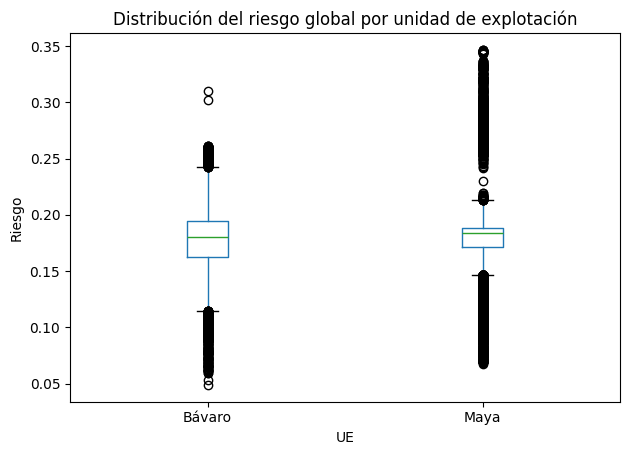

In [16]:
# CELDA 5. RIESGO GLOBAL


# -------------------------
# MAYA
# -------------------------
print("MAYA - Riesgo global")


df_m_riesgo = riesgo_global(df_m_anom)

print("Número de registros con Riesgo > 0.35 (Maya):")
print(len(df_m_riesgo[df_m_riesgo["Riesgo"] > 0.35]))

display(df_m_riesgo[df_m_riesgo["Riesgo"] > 0.35].head())

# -------------------------
# BÁVARO
# -------------------------
print("\n" + "-" * 100)
print("\n")

print("BÁVARO - Riesgo global")

df_b_riesgo = riesgo_global(df_b_anom)

print("Número de registros con Riesgo > 0.35 (Bávaro):")
print(len(df_b_riesgo[df_b_riesgo["Riesgo"] > 0.30]))

display(df_b_riesgo[df_b_riesgo["Riesgo"] > 0.30].head())

# ============================================================
# FIGURA 7.7. DISTRIBUCIÓN DEL RIESGO GLOBAL POR UE
# ============================================================

df_fig_77 = pd.concat([
    df_m_riesgo[["Riesgo"]].assign(UE="Maya"),
    df_b_riesgo[["Riesgo"]].assign(UE="Bávaro")
], ignore_index=True)

plt.figure(figsize=(8, 5))
df_fig_77.boxplot(column="Riesgo", by="UE", grid=False)

plt.suptitle("")
plt.title("Distribución del riesgo global por unidad de explotación")
plt.ylabel("Riesgo")
plt.xlabel("UE")
plt.tight_layout()
plt.show()

#plt.figure(figsize=(9, 5))
#plt.hist(df_m_riesgo["Riesgo"].dropna(), bins=30, alpha=0.6, label="Maya", color="#4C78A8")
#plt.hist(df_b_riesgo["Riesgo"].dropna(), bins=30, alpha=0.6, label="Bávaro", color="#F58518")
#plt.title("Distribución del riesgo global por UE")
#plt.xlabel("Riesgo")
#plt.ylabel("Frecuencia")
#plt.legend()
#plt.grid(alpha=0.3)
#plt.tight_layout()
#plt.show()




MAYA - Clustering
Estadísticas de clustering (Maya)


ImpteML                        Demora                Antigüedad  \
               mean      median        std   mean median     std       mean   
Cluster                                                                       
0       -142463.523 -122651.150  60456.812  3.826    0.0  38.192      7.716   
1       -496088.365 -547758.681  78629.503 -3.272    0.0  40.047      0.121   
2         -7806.135   -3108.840  13706.799  7.387    0.0  59.150     13.038   

                       zs_score  ... Duplicado_score Outlier_score         \
        median     std     mean  ...             std          mean median   
Cluster                          ...                                        
0          0.0  37.683    0.008  ...           0.067         0.117  0.125   
1          0.0  41.008    0.012  ...           0.108        -0.015 -0.008   
2          5.0  59.347    0.010  ...           0.228         0.153  0.183   

               Riesgo               Delta_fecha_doc                
           std   mean median    std            mean median    std  
Cluster                                                            
0        0.054  0.152  0.154  0.022           2.804    1.0  5.469  
1        0.062  0.119  0.110  0.023           2.092    0.0  5.969  
2        0.071  0.189  0.184  0.036           3.780    2.0  5.770  

[3 rows x 24 columns]

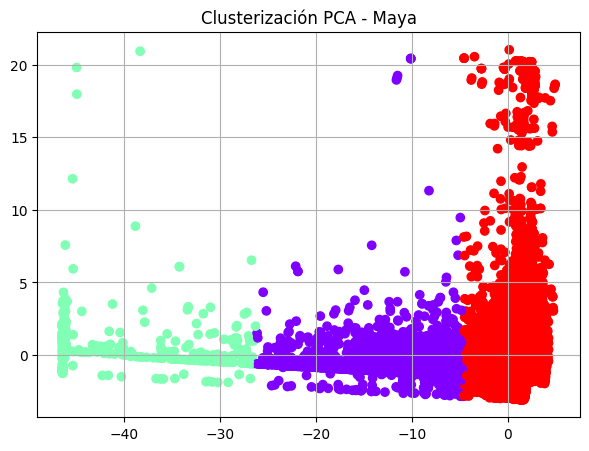


----------------------------------------------------------------------------------------------------


BÁVARO - Clustering
Estadísticas de clustering (Bávaro)


ImpteML                        Demora                Antigüedad  \
               mean    median         std    mean median     std       mean   
Cluster                                                                       
0        -15733.478   -804.44  106744.796  92.892   89.0  65.251     62.525   
1       -263248.302  -2737.18  569688.594  39.245    0.0  64.730     23.519   
2       -102229.678 -19800.00  257947.201  -2.884   -3.0  31.744    -30.176   

                       zs_score  ... Duplicado_score Outlier_score         \
        median     std     mean  ...             std          mean median   
Cluster                          ...                                        
0         70.0  73.259    0.016  ...           0.257         0.055  0.060   
1          0.0  61.486    0.037  ...           0.206         0.019  0.019   
2        -24.0  43.737    0.003  ...           0.107         0.221  0.235   

               Riesgo               Delta_fecha_doc                
           std   mean median    std            mean median    std  
Cluster                                                            
0        0.078  0.163  0.152  0.036           1.689    0.0  4.646  
1        0.070  0.135  0.123  0.038           1.736    0.0  4.698  
2        0.058  0.180  0.181  0.021           8.780    8.0  6.575  

[3 rows x 24 columns]

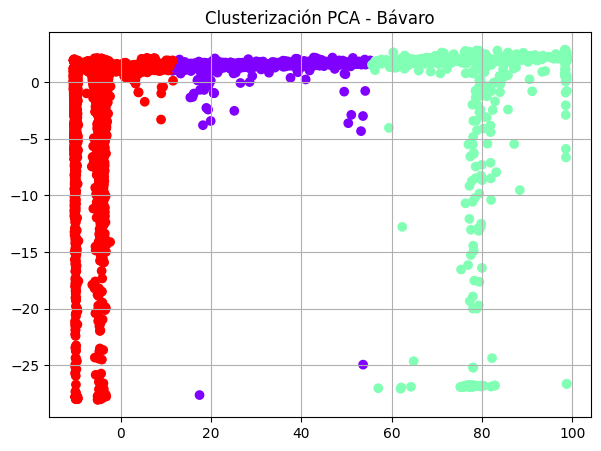

In [17]:

# CELDA 6. CLUSTERING

# -------------------------
# MAYA
# -------------------------

print("MAYA - Clustering")


df_m_cluster, stats_cluster_m = cluster_kmeans(df_m_riesgo)

print("Estadísticas de clustering (Maya)")
display(stats_cluster_m)

plt.figure(figsize=(7, 5))
plt.scatter(df_m_cluster["PC1"], df_m_cluster["PC2"], c=df_m_cluster["Cluster"], cmap="rainbow")
plt.title("Clusterización PCA - Maya")
plt.grid(True)
plt.show()

# -------------------------
# BÁVARO
# -------------------------

print("\n" + "-" * 100)
print("\n")

print("BÁVARO - Clustering")

df_b_cluster, stats_cluster_b = cluster_kmeans(df_b_riesgo)

print("Estadísticas de clustering (Bávaro)")
display(stats_cluster_b)

plt.figure(figsize=(7, 5))
plt.scatter(df_b_cluster["PC1"], df_b_cluster["PC2"], c=df_b_cluster["Cluster"], cmap="rainbow")
plt.title("Clusterización PCA - Bávaro")
plt.grid(True)
plt.show()

In [18]:
# CELDA 7. RANDOM FOREST REGRESSOR

# -------------------------
# MAYA
# -------------------------
print("MAYA - Random Forest Regressor")

df_m_reg, model_reg_m = rf_regressor(df_m_cluster, model_path="models_m/meta_rf.pkl")

df_m_rf = df_m_reg[
    ['UE', 'Sociedad', 'Cuenta', "zs_score", 'Casuística', "Outlier",
     "Duplicado", "Demora", "Antigüedad", "ImpteML",
     'Riesgo', 'Riesgo_rf', 'Riesgo_final']
]

display(df_m_rf.head())

y_true_m = df_m_reg["Riesgo"].astype(float).fillna(0).values
y_pred_m = df_m_reg["Riesgo_rf"].astype(float).fillna(0).values

eval_reg_m = pd.DataFrame([{
    "MAE": mean_absolute_error(y_true_m, y_pred_m),
    "RMSE": rmse(y_true_m, y_pred_m),
    "corr": np.corrcoef(y_true_m, y_pred_m)[0,1] if len(y_true_m) > 1 else np.nan
}]).round(4)

print("Evaluación regressor (Maya)")
display(eval_reg_m)

# -------------------------
# BÁVARO
# -------------------------
print("\n" + "-" * 100)
print("\n")

print("BÁVARO - Random Forest Regressor")

df_b_reg, model_reg_b = rf_regressor(df_b_cluster, model_path="models_b/meta_rf.pkl")

df_b_rf = df_b_reg[
    ['UE', 'Sociedad', 'Cuenta', "zs_score", 'Casuística', "Outlier",
     "Duplicado", "Demora", "Antigüedad", "ImpteML",
     'Riesgo', 'Riesgo_rf', 'Riesgo_final']
]

display(df_b_rf.head())

y_true_b = df_b_reg["Riesgo"].astype(float).fillna(0).values
y_pred_b = df_b_reg["Riesgo_rf"].astype(float).fillna(0).values

eval_reg_b = pd.DataFrame([{
    "MAE": mean_absolute_error(y_true_b, y_pred_b),
    "RMSE": rmse(y_true_b, y_pred_b),
    "corr": np.corrcoef(y_true_b, y_pred_b)[0,1] if len(y_true_b) > 1 else np.nan
}]).round(4)

print("Evaluación regressor (Bávaro)")
display(eval_reg_b)

MAYA - Random Forest Regressor


,UE,Sociedad,Cuenta,zs_score,Casuística,Outlier,Duplicado,Demora,Antigüedad,ImpteML,Riesgo,Riesgo_rf,Riesgo_final
0,Maya,5601,Prov_0001,0.002570,0.0,1,0,432.0,439.0,-1832.8,0.1564,0.155001,0.155560
1,Maya,5601,Prov_0001,0.002578,0.0,1,0,432.0,439.0,-2285.2,0.1560,0.155157,0.155494
2,Maya,5601,Prov_0001,0.002520,0.0,1,0,432.0,439.0,-5005.4,0.1458,0.146183,0.146030
3,Maya,5601,Prov_0001,0.002564,0.0,1,0,432.0,439.0,-452.4,0.1461,0.146431,0.146299
4,Maya,5601,Prov_0001,0.002533,0.0,1,0,432.0,439.0,-3665.6,0.1458,0.146177,0.146026


Evaluación regressor (Maya)


,MAE,RMSE,corr
0,0.0001,0.0004,0.9999



----------------------------------------------------------------------------------------------------


BÁVARO - Random Forest Regressor


,UE,Sociedad,Cuenta,zs_score,Casuística,Outlier,Duplicado,Demora,Antigüedad,ImpteML,Riesgo,Riesgo_rf,Riesgo_final
0,Bavaro,7400,Prov_0017,0.005610,0.0,1,0,188.0,157.0,-1307.52,0.1213,0.121877,0.121646
1,Bavaro,7400,Prov_0017,0.034024,0.0,1,0,188.0,157.0,-2657.54,0.1083,0.109297,0.108898
2,Bavaro,7400,Prov_0017,0.028611,0.0,1,1,188.0,157.0,-2679.88,0.2341,0.235503,0.234942
3,Bavaro,7400,Prov_0017,0.008299,0.0,1,1,188.0,157.0,-2679.88,0.2362,0.236892,0.236615
4,Bavaro,7400,Prov_0017,0.021085,0.0,1,1,188.0,157.0,-1891.84,0.2369,0.237318,0.237151


Evaluación regressor (Bávaro)


,MAE,RMSE,corr
0,0.0001,0.0004,0.9998


MAYA - Random Forest Classifier


,UE,Sociedad,Cuenta,zs_score,Casuística,Outlier,Duplicado,Demora,Antigüedad,ImpteML,Riesgo,Riesgo_rf,Riesgo_final,Riesgo_clase_rf
0,Maya,5601,Prov_0001,0.002570,0.0,1,0,432.0,439.0,-1832.8,0.1564,0.155001,0.155560,Bajo
1,Maya,5601,Prov_0001,0.002578,0.0,1,0,432.0,439.0,-2285.2,0.1560,0.155157,0.155494,Bajo
2,Maya,5601,Prov_0001,0.002520,0.0,1,0,432.0,439.0,-5005.4,0.1458,0.146183,0.146030,Bajo
3,Maya,5601,Prov_0001,0.002564,0.0,1,0,432.0,439.0,-452.4,0.1461,0.146431,0.146299,Bajo
4,Maya,5601,Prov_0001,0.002533,0.0,1,0,432.0,439.0,-3665.6,0.1458,0.146177,0.146026,Bajo


Distribución de clases de riesgo (Maya)


Riesgo_clase_rf
Bajo     29317
Medio     3138
Name: count, dtype: int64


----------------------------------------------------------------------------------------------------


BÁVARO - Random Forest Classifier


,UE,Sociedad,Cuenta,zs_score,Casuística,Outlier,Duplicado,Demora,Antigüedad,ImpteML,Riesgo,Riesgo_rf,Riesgo_final,Riesgo_clase_rf
0,Bavaro,7400,Prov_0017,0.005610,0.0,1,0,188.0,157.0,-1307.52,0.1213,0.121877,0.121646,Bajo
1,Bavaro,7400,Prov_0017,0.034024,0.0,1,0,188.0,157.0,-2657.54,0.1083,0.109297,0.108898,Bajo
2,Bavaro,7400,Prov_0017,0.028611,0.0,1,1,188.0,157.0,-2679.88,0.2341,0.235503,0.234942,Bajo
3,Bavaro,7400,Prov_0017,0.008299,0.0,1,1,188.0,157.0,-2679.88,0.2362,0.236892,0.236615,Bajo
4,Bavaro,7400,Prov_0017,0.021085,0.0,1,1,188.0,157.0,-1891.84,0.2369,0.237318,0.237151,Bajo


Distribución de clases de riesgo (Bávaro)


Riesgo_clase_rf
Bajo     16009
Medio      222
Name: count, dtype: int64

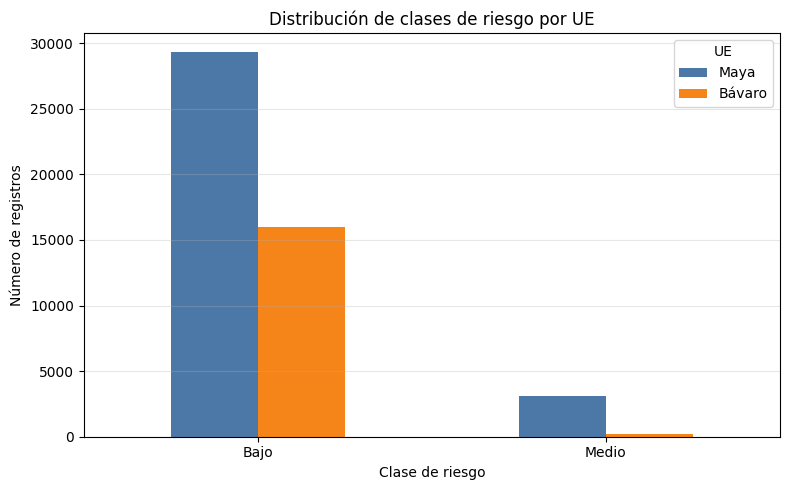

In [19]:
# CELDA 8. RANDOM FOREST CLASSIFIER

# -------------------------
# MAYA
# -------------------------
print("MAYA - Random Forest Classifier")

df_m_cls_base, model_cls_m = rf_classifier(df_m_reg, model_path="models_m/class_rf.pkl")

df_m_cls = df_m_cls_base[
    ['UE', 'Sociedad', 'Cuenta', "zs_score", 'Casuística', "Outlier",
     "Duplicado", "Demora", "Antigüedad", "ImpteML",
     'Riesgo', 'Riesgo_rf', 'Riesgo_final', 'Riesgo_clase_rf']
]

display(df_m_cls.head())

print("Distribución de clases de riesgo (Maya)")
display(df_m_cls["Riesgo_clase_rf"].value_counts(dropna=False))

# -------------------------
# BÁVARO
# -------------------------
print("\n" + "-" * 100)
print("\n")

print("BÁVARO - Random Forest Classifier")

df_b_cls_base, model_cls_b = rf_classifier(df_b_reg, model_path="models_b/class_rf.pkl")

df_b_cls = df_b_cls_base[
    ['UE', 'Sociedad', 'Cuenta', "zs_score", 'Casuística', "Outlier",
     "Duplicado", "Demora", "Antigüedad", "ImpteML",
     'Riesgo', 'Riesgo_rf', 'Riesgo_final', 'Riesgo_clase_rf']
]

display(df_b_cls.head())

print("Distribución de clases de riesgo (Bávaro)")
display(df_b_cls["Riesgo_clase_rf"].value_counts(dropna=False))

# ============================================================
# FIGURA 7.10. DISTRIBUCIÓN DE CLASES DE RIESGO POR UE
# ============================================================

cls_m = df_m_cls_base["Riesgo_clase_rf"].value_counts(dropna=False).rename("Maya")
cls_b = df_b_cls_base["Riesgo_clase_rf"].value_counts(dropna=False).rename("Bávaro")

df_fig_710 = pd.concat([cls_m, cls_b], axis=1).fillna(0)

ax = df_fig_710.plot(
    kind="bar",
    figsize=(8, 5),
    color=["#4C78A8", "#F58518"]
)

plt.title("Distribución de clases de riesgo por UE")
plt.xlabel("Clase de riesgo")
plt.ylabel("Número de registros")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="UE")
plt.tight_layout()
plt.show()


In [20]:
# CELDA 9. ESTADÍSTICAS GLOBALES

# -------------------------
# MAYA
# -------------------------
print("MAYA - Estadísticas globales")

stats_global_m = global_stats(df_m_cls_base)
display(stats_global_m)

# -------------------------
# BÁVARO
# -------------------------
print("\n" + "-" * 100)
print("\n")

print("BÁVARO - Estadísticas globales")

stats_global_b = global_stats(df_b_cls_base)
display(stats_global_b)

MAYA - Estadísticas globales


,total_facturas,facturas_riesgo_alto,pct_riesgo_alto,riesgo_medio_global,riesgo_p95_global,importe_riesgo_total,riesgo_ponderado_global,duplicados_total,pct_duplicados,anomalias_total,pct_anomalias
0,32455,0,0.0,0.185895,0.287025,1.150158e+08,0.149501,3150,0.097057,1622,0.049977



----------------------------------------------------------------------------------------------------


BÁVARO - Estadísticas globales


,total_facturas,facturas_riesgo_alto,pct_riesgo_alto,riesgo_medio_global,riesgo_p95_global,importe_riesgo_total,riesgo_ponderado_global,duplicados_total,pct_duplicados,anomalias_total,pct_anomalias
0,16231,0,0.0,0.177611,0.200106,2.475723e+08,0.145524,460,0.028341,812,0.050028


In [21]:
# ============================================================
# CELDA 10. CONSOLIDACIÓN DE RESULTADOS DE MAYA Y BÁVARO
# ============================================================

print("CONSOLIDACIÓN DE MAYA Y BÁVARO")

# Unimos los resultados enriquecidos de ambas UEs
df = pd.concat([df_m_cls_base, df_b_cls_base], ignore_index=True)

print("Dimensión dataset conjunto:", df.shape)

CONSOLIDACIÓN DE MAYA Y BÁVARO
Dimensión dataset conjunto: (48686, 46)


ANÁLISIS GENERAL POR UNIDAD DE EXPLOTACIÓN
[Duplicados_UE] sequence item 2: expected str instance, float found

KPIs por UE

UE: Maya


,UE,n_facturas,importe_total,importe_medio,riesgo_medio,riesgo_p95,pct_riesgo_alto,mora_media,pct_pago_tarde,pct_pago_anticipado,antig_media,delta_doc_media,pct_registros_tarde,duplicados,pct_duplicados,anomalias,pct_anomalias,n_proveedores,proveedor_mayor_gasto
1,Maya,32455,-7.354148e+08,-22659.523292,0.185895,0.287025,0.0,7.030504,0.424187,0.455924,12.553135,3.701833,0.776306,3150,0.097057,1622,0.049977,947,Prov_0188



UE: Bavaro


,UE,n_facturas,importe_total,importe_medio,riesgo_medio,riesgo_p95,pct_riesgo_alto,mora_media,pct_pago_tarde,pct_pago_anticipado,antig_media,delta_doc_media,pct_registros_tarde,duplicados,pct_duplicados,anomalias,pct_anomalias,n_proveedores,proveedor_mayor_gasto
0,Bavaro,16231,-1.682408e+09,-103654.023058,0.177611,0.200106,0.0,2.967654,0.357587,0.503235,-24.077629,8.214657,0.796439,460,0.028341,812,0.050028,677,Prov_0017



Zero-Shot por UE


zs_label,Cambio de forma de pago,Cumple normalidad,Fecha fuera de periodo,Pago duplicado o similar,Posible fraccionamiento de pagos,Proveedor sensible,Texto o referencia ambigua,Términos de pago atípicos,Urgencia inusual
UE,,,,,,,,,
Bavaro,201,53,12787,115,689,1996,89,164,137
Maya,1121,608,17658,1183,2968,3884,319,4143,571



Duplicados por UE


""



Resumen general


{'UE_mayor_riesgo': 'Maya',
 'UE_mas_anomalias': 'Maya',
 'UE_mas_duplicados': 'Maya',
 'UE_mas_mora': 'Maya',
 'UE_mas_antiguedad': 'Maya'}

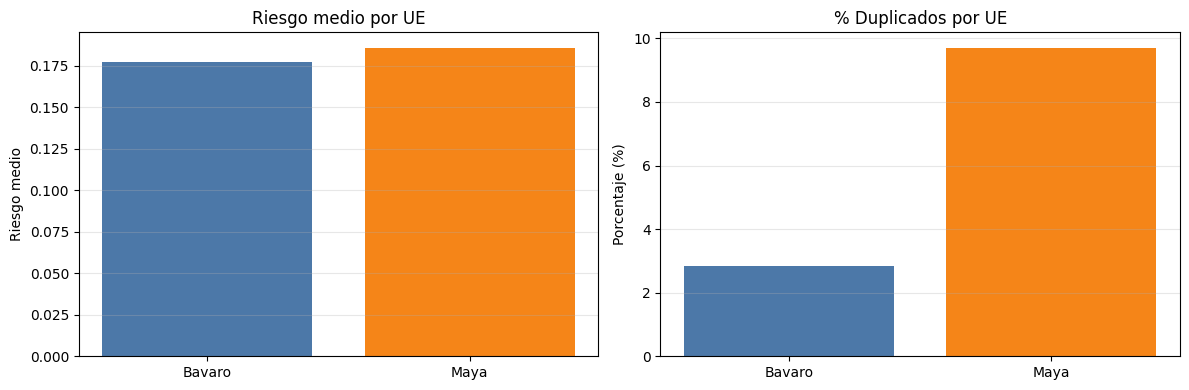

In [22]:
# CELDA 11. ANÁLISIS GENERAL POR UE

print("ANÁLISIS GENERAL POR UNIDAD DE EXPLOTACIÓN")

analisis_ue = analisis_UE(df)

print("\nKPIs por UE")
for ue in df["UE"].dropna().unique():
    print(f"\nUE: {ue}")
    display(analisis_ue["KPIS_UE"][analisis_ue["KPIS_UE"]["UE"] == ue])

print("\nZero-Shot por UE")
display(analisis_ue["zs_ue"])

print("\nDuplicados por UE")
display(analisis_ue["Duplicados_UE"])

print("\nResumen general")
display(analisis_ue["Resumen"])



kpis_ue = analisis_ue["KPIS_UE"].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(kpis_ue["UE"], kpis_ue["riesgo_medio"], color=["#4C78A8", "#F58518"])
axes[0].set_title("Riesgo medio por UE")
axes[0].set_ylabel("Riesgo medio")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(kpis_ue["UE"], kpis_ue["pct_duplicados"] * 100, color=["#4C78A8", "#F58518"])
axes[1].set_title("% Duplicados por UE")
axes[1].set_ylabel("Porcentaje (%)")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# CELDA 13. KPIs POR PROVEEDOR EN CADA UE

print("KPIs POR PROVEEDOR")

for ue in df["UE"].dropna().unique():
    print(f"\nUE: {ue}")
    display(proveedor_kpis(df[df["UE"] == ue]))

KPIs POR PROVEEDOR

UE: Maya


,Cuenta,n_facturas,importe_total,importe_medio,coef_variacion_importe,riesgo_medio,riesgo_p95,pct_riesgo_alto,riesgo_ponderado,n_duplicados,...,pct_anomalias,mora_media,mora_p95,pct_pago_tarde,pct_pago_anticipado,antiguedad_media,delta_doc_media,pct_registros_tarde,zs_score_medio,hhi_por_ue
0,Prov_0001,42.0,-1.896948e+05,-4516.542857,-1.933791,0.146391,0.155560,0.0,0.129919,0.0,...,0.880952,387.714286,432.00,0.928571,0.000000,395.261905,0.000000,0.000000,0.009613,1.0
1,Prov_0002,40.0,-2.585384e+04,-646.346000,-3.654015,0.221759,0.287093,0.0,0.192108,24.0,...,0.650000,190.925000,432.00,0.750000,0.075000,196.825000,0.550000,0.050000,0.022485,1.0
2,Prov_0003,1135.0,-2.655035e+07,-23392.381527,-2.350437,0.183653,0.196809,0.0,0.162174,32.0,...,0.018502,29.177974,61.00,0.938326,0.036123,27.421145,2.037004,0.736564,0.003323,1.0
3,Prov_0004,37.0,-7.852696e+05,-21223.502162,-1.625896,0.187834,0.290716,0.0,0.160034,6.0,...,0.162162,22.810811,284.80,0.270270,0.513514,26.270270,6.837838,0.729730,0.012495,1.0
4,Prov_0005,14.0,-1.116656e+06,-79761.126700,-2.405146,0.181181,0.280022,0.0,0.212683,6.0,...,0.857143,190.071429,382.60,0.857143,0.000000,189.357143,2.142857,0.642857,0.073489,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
942,Prov_0943,2.0,-1.615398e+04,-8076.990000,-0.000000,0.170788,0.186959,0.0,0.170788,0.0,...,0.000000,4.500000,8.55,0.500000,0.000000,3.000000,7.000000,0.500000,0.005036,1.0
943,Prov_0944,2.0,-2.363060e+04,-11815.300000,-0.000000,0.166804,0.178868,0.0,0.166804,0.0,...,0.000000,-10.500000,-1.05,0.000000,0.500000,-10.500000,2.500000,0.500000,0.009322,1.0
944,Prov_0945,2.0,-2.274000e+03,-1137.000000,-0.000000,0.170046,0.184756,0.0,0.170046,0.0,...,0.000000,-6.000000,-0.60,0.000000,0.500000,4.000000,6.000000,0.500000,0.007746,1.0
945,Prov_0946,4.0,-4.903696e+04,-12259.240000,-0.918781,0.179079,0.188940,0.0,0.169586,0.0,...,0.000000,5.250000,7.00,0.750000,0.000000,2.250000,3.000000,0.750000,0.005109,1.0



UE: Bavaro


,Cuenta,n_facturas,importe_total,importe_medio,coef_variacion_importe,riesgo_medio,riesgo_p95,pct_riesgo_alto,riesgo_ponderado,n_duplicados,...,pct_anomalias,mora_media,mora_p95,pct_pago_tarde,pct_pago_anticipado,antiguedad_media,delta_doc_media,pct_registros_tarde,zs_score_medio,hhi_por_ue
0,Prov_0017,1163.0,-7421214.241,-6.381096e+03,-14.659764,0.163049,0.250958,0.0,0.128348,188.0,...,0.360275,109.687876,188.00,0.954428,0.000000,80.761823,0.114359,0.097163,0.016481,1.0
1,Prov_0276,14.0,188278.744,1.344848e+04,1.591840,0.141845,0.216207,0.0,0.143906,0.0,...,0.000000,21.500000,56.00,0.785714,0.071429,21.500000,6.264286,0.714286,0.018334,1.0
2,Prov_0372,7.0,-925610.022,-1.322300e+05,-1.171338,0.174544,0.210119,0.0,0.168249,0.0,...,0.000000,-10.142857,3.50,0.142857,0.428571,-21.857143,13.200000,0.571429,0.002463,1.0
3,Prov_0547,3.0,-4389193.858,-1.463065e+06,-0.454001,0.106514,0.120316,0.0,0.102317,0.0,...,0.333333,-4.666667,9.90,0.333333,0.333333,-73.333333,10.233333,0.666667,0.002221,1.0
4,Prov_0570,9.0,-1340994.700,-1.489994e+05,-0.760582,0.166301,0.194595,0.0,0.161622,0.0,...,0.000000,-2.222222,11.00,0.333333,0.333333,-36.666667,9.855556,0.666667,0.005039,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
672,Prov_1612,2.0,-408517.880,-2.042589e+05,-0.000000,0.169938,0.187251,0.0,0.169938,0.0,...,0.000000,4.500000,8.55,0.500000,0.000000,-1.500000,6.500000,0.500000,0.002153,1.0
673,Prov_1613,2.0,-1704336.140,-8.521681e+05,-0.000000,0.142202,0.157079,0.0,0.142202,0.0,...,0.000000,-5.000000,-0.50,0.000000,0.500000,-6.500000,1.500000,0.500000,0.001894,1.0
674,Prov_1614,2.0,63461.858,3.173093e+04,0.000000,0.171733,0.208317,0.0,0.171733,0.0,...,0.000000,2.000000,3.80,0.500000,0.000000,2.000000,0.000000,0.000000,0.008523,1.0
675,Prov_1615,2.0,-1592321.640,-7.961608e+05,-0.000000,0.126082,0.129408,0.0,0.126082,0.0,...,0.000000,-9.000000,-0.90,0.000000,0.500000,-11.500000,2.500000,0.500000,0.020054,1.0


In [24]:
# CELDA 14. PROVEEDORES COMUNES ENTRE MAYA Y BÁVARO

print("PROVEEDORES COMUNES ENTRE UEs")

proveedores_maya = set(df[df["UE"] == "Maya"]["Cuenta"].dropna().unique())
proveedores_bavaro = set(df[df["UE"] == "Bávaro"]["Cuenta"].dropna().unique())

proveedores_comunes = proveedores_maya.intersection(proveedores_bavaro)

print("Número de proveedores comunes:", len(proveedores_comunes))

df_proveedores_comunes = df[df["Cuenta"].isin(proveedores_comunes)].copy()

display(df_proveedores_comunes[["UE", "Sociedad", "Cuenta", "Nombre1", "ImpteML", "Riesgo_final"]].head(20))

PROVEEDORES COMUNES ENTRE UEs
Número de proveedores comunes: 0


,UE,Sociedad,Cuenta,Nombre1,ImpteML,Riesgo_final


In [25]:
resumen_comunes = (
    df_proveedores_comunes
    .groupby(["Cuenta", "UE"])
    .agg({
        "ImpteML": "sum",
        "Riesgo_final": "mean"
    })
    .reset_index()
)

display(resumen_comunes.head(20))

,Cuenta,UE,ImpteML,Riesgo_final


CLUSTERING DE PROVEEDORES POR UE
 Stats para: GLOBAL


,n_facturas,importe_total,importe_medio,coef_variacion_importe,riesgo_medio,riesgo_p95,pct_riesgo_alto,mora_media,pct_pago_tarde,pct_pago_anticipado,antiguedad_media,delta_doc_media,pct_registros_tarde,n_duplicados,pct_duplicados,n_anomalias,pct_anomalias,zs_score_medio,hhi_por_ue
Cluster,,,,,,,,,,,,,,,,,,,
0,27.484667,-1.554647e+06,-8.514308e+04,8.414527e-01,0.169984,0.191363,0.0,-1.405544,0.264314,0.402487,-8.379283,5.607122,0.592734,0.916000,0.010561,0.662667,0.032608,0.008369,0.998730
1,75.285714,-8.760531e+05,-3.364287e+04,9.630159e+00,0.191837,0.255653,0.0,127.398487,0.622332,0.080101,127.741953,4.074625,0.432547,22.775510,0.347437,14.500000,0.468102,0.028653,0.996689
2,4.500000,-1.010550e-13,-5.944410e-15,7.497523e+12,0.158246,0.178935,0.0,39.102303,0.565212,0.118900,27.044880,5.872915,0.505805,0.222222,0.044444,1.055556,0.201190,0.027234,0.000000



 PCA para: GLOBAL


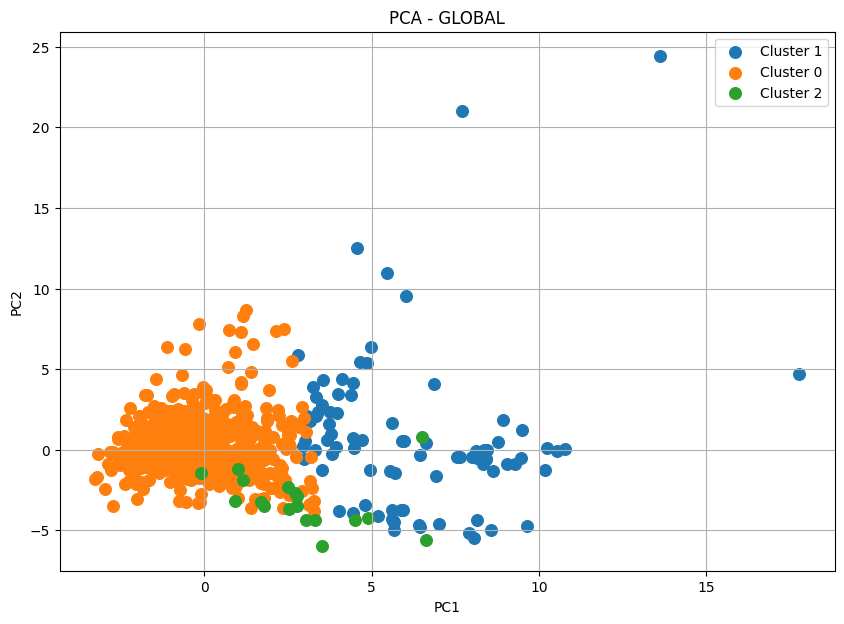

 Stats para: Maya


,n_facturas,importe_total,importe_medio,coef_variacion_importe,riesgo_medio,riesgo_p95,pct_riesgo_alto,mora_media,pct_pago_tarde,pct_pago_anticipado,antiguedad_media,delta_doc_media,pct_registros_tarde,n_duplicados,pct_duplicados,n_anomalias,pct_anomalias,zs_score_medio,hhi_por_ue
Cluster,,,,,,,,,,,,,,,,,,,
0,651.800000,-1.075987e+07,-22414.011525,-3.258517e+00,0.198909,0.252396,0.0,1.301342,0.490824,0.485171,4.035751,2.838119,0.889795,93.850000,0.183808,26.550000,0.044816,0.007541,1.000000
1,21.787736,-5.859531e+05,-38626.118967,1.069493e+09,0.169798,0.193044,0.0,2.414241,0.315875,0.343171,6.224262,4.857059,0.539437,1.074292,0.023057,0.660377,0.043886,0.012039,0.998821
2,11.936709,-2.953048e+05,-28408.898759,1.091798e+12,0.176722,0.231639,0.0,166.569626,0.603488,0.023316,168.478519,4.430129,0.303982,4.582278,0.270219,6.721519,0.523512,0.032312,0.873418



 PCA para: Maya


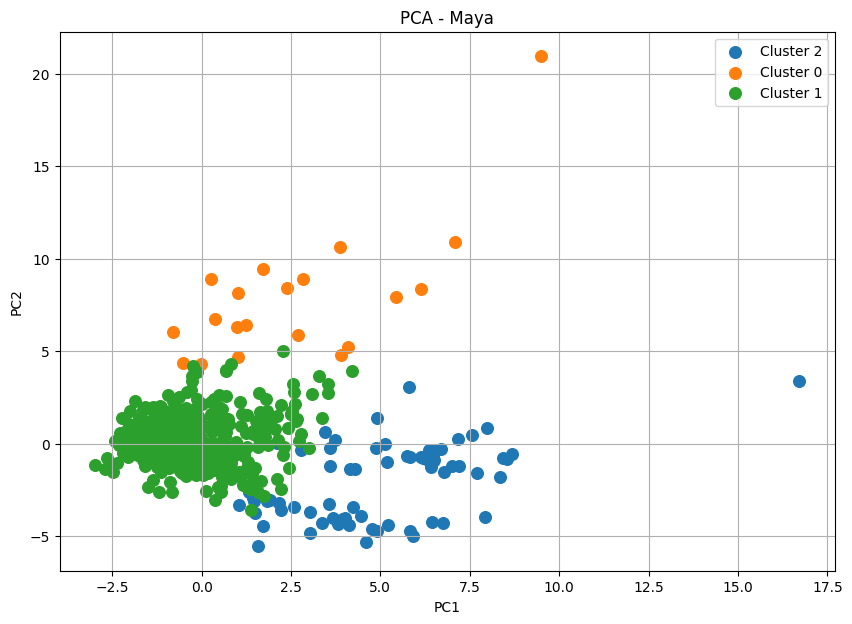

 Stats para: Bavaro


,n_facturas,importe_total,importe_medio,coef_variacion_importe,riesgo_medio,riesgo_p95,pct_riesgo_alto,mora_media,pct_pago_tarde,pct_pago_anticipado,antiguedad_media,delta_doc_media,pct_registros_tarde,n_duplicados,pct_duplicados,n_anomalias,pct_anomalias,zs_score_medio,hhi_por_ue
Cluster,,,,,,,,,,,,,,,,,,,
0,22.828704,-2.543428e+06,-140506.604531,-9.212990e-01,0.171971,0.191724,0.0,-6.969725,0.204874,0.472053,-28.094716,6.680936,0.664600,0.344136,0.004848,0.430556,0.012457,0.003673,1.00
1,9.821429,-9.587792e+05,-213882.857033,1.707015e+12,0.155426,0.188351,0.0,18.096556,0.421068,0.262062,1.999172,3.978940,0.539838,1.750000,0.106901,4.071429,0.407837,0.022667,0.75
2,1163.000000,-7.421214e+06,-6381.095650,-1.465976e+01,0.163049,0.250958,0.0,109.687876,0.954428,0.000000,80.761823,0.114359,0.097163,188.000000,0.161651,419.000000,0.360275,0.016481,1.00



 PCA para: Bavaro


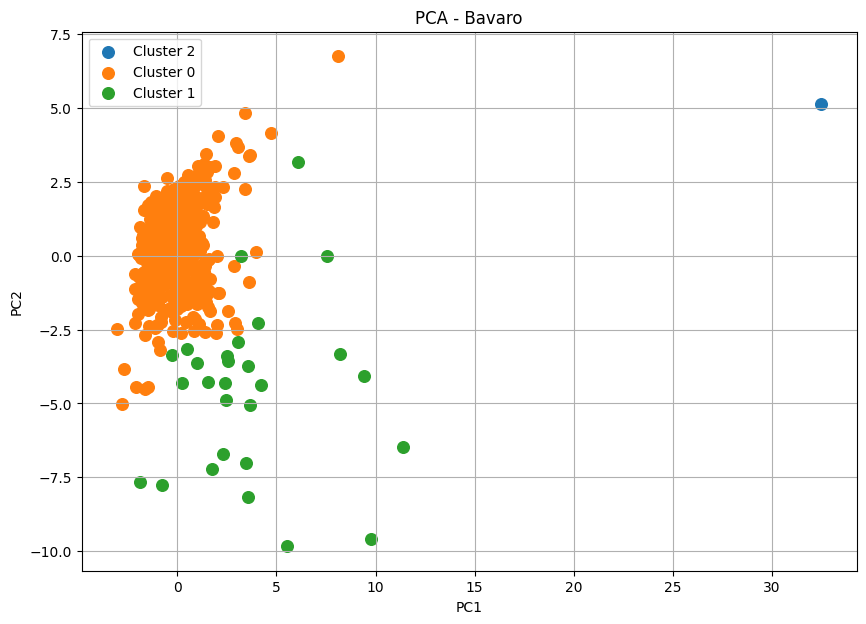

In [26]:
# CELDA 15. CLUSTERING DE PROVEEDORES

print("CLUSTERING DE PROVEEDORES POR UE")

proveedor_results = clustering_proveedores(df)

stats_ue = pd.concat(
    {key: result["stats"] for key, result in proveedor_results.items()},
    names=["UE", "Cluster"]
)

for ue in stats_ue.index.levels[0]:
    print(f" Stats para: {ue}")

    # Mostrar estadísticas
    display(stats_ue.loc[ue])

    if ue in proveedor_results and "df" in proveedor_results[ue]:

        tabla_cluster = proveedor_results[ue]["df"]

        if "Cluster_proveedor" in tabla_cluster.columns:
            print(f"\n PCA para: {ue}")
            pca_clustering_proveedores(tabla_cluster, f"PCA - {ue}")
        else:
            print(f"\n {ue}: No hay clusters suficientes para generar PCA.")

# SERIES TEMPORALES

In [27]:
# CELDA 16. PREPARACIÓN DE SERIES TEMPORALES

df_ts = pd.concat([df_maya_anonim, df_bavaro_anonim], ignore_index = True)
df_ts, df_casos,df_anticipos, df_zs, df_dup, df_if, df_rg, df_cluster, stats_cluster, df_rf, df_cls, stats_global, proveedores_kpis, analisis_ue, clust_proveedores = run_pipeline(df_ts)

42 partidas detectadas como anticipos (407)
0 partidas detectadas como retenciones (40010001)
[Duplicados_UE] sequence item 1: expected str instance, float found


In [28]:


df_ts["Registrado2"] = pd.to_datetime(df_ts["Registrado"], errors="coerce")
df_ts["periodo"] = df_ts["Registrado2"].dt.to_period("M")
df_ts["periodo_dt"] = df_ts["periodo"].dt.to_timestamp()

fecha_col = "periodo_dt"

df_ts = df_ts.sort_values(fecha_col)

numeric_cols = [
    "ImpteML", "Duplicado", "Outlier", "Riesgo_final",
    "Antigüedad", "Demora", "Delta_fecha_doc"
]
df_ts[numeric_cols] = df_ts[numeric_cols].apply(pd.to_numeric, errors="coerce")

In [29]:
# CELDA 17. AGREGACIÓN TEMPORAL

df_res = (
    df_ts.set_index(fecha_col)
         .groupby(["UE", "Cuenta"])
         .resample("MS")
         .agg({
             "ImpteML": "sum",
             "Duplicado": "sum",
             "Outlier": "sum",
             "Riesgo_final": "mean",
             "Antigüedad": "mean",
             "Demora": "mean",
             "Delta_fecha_doc": "mean",
         })
         .reset_index()
)

df_res["n_facturas"] = (
    df_ts.set_index(fecha_col)
         .groupby(["UE", "Cuenta"])
         .resample("MS")
         .size()
         .values
)

df_res["pct_duplicados"] = df_res["Duplicado"] / df_res["n_facturas"]
df_res["pct_anomalias"] = df_res["Outlier"] / df_res["n_facturas"]

df_res["pct_duplicados"].replace([np.inf, -np.inf], 0, inplace=True)
df_res["pct_anomalias"].replace([np.inf, -np.inf], 0, inplace=True)


C:\Users\IrenePalomaresCastro\AppData\Local\Temp\ipykernel_1296\737543920.py:30: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_res["pct_duplicados"].replace([np.inf, -np.inf], 0, inplace=True)
C:\Users\IrenePalomaresCastro\AppData\Local\Temp\ipykernel_1296\737543920.py:31: ChainedAssignmentError: A value is being set on a copy of 

0        1.000000
1        1.000000
2        0.582418
3        0.277778
4        0.147059
           ...   
23778    0.000000
23779    0.000000
23780    0.000000
23781    0.000000
23782    0.000000
Name: pct_anomalias, Length: 23783, dtype: float64

In [30]:
# CELDA 18. AGREGACIÓN GLOBAL Y POR UE

vars_agg = {
    "ImpteML": "sum",
    "n_facturas": "sum",
    "pct_duplicados": "mean",
    "pct_anomalias": "mean",
    "Riesgo_final": "mean",
    "Antigüedad": "mean",
    "Demora": "mean",
    "Delta_fecha_doc": "mean"
}

# GLOBAL
df_region_mes = df_res.groupby("periodo_dt").agg(vars_agg).reset_index()
df_region_mes["UE"] = "GLOBAL"

# POR UE
df_ue_mes = df_res.groupby(["UE", "periodo_dt"]).agg(vars_agg).reset_index()

print("Resumen global")
display(df_region_mes.head())

print("\nResumen por UE")

for ue in df_ue_mes["UE"].dropna().unique():
    print(f"\nUE: {ue}")
    display(df_ue_mes[df_ue_mes["UE"]==ue].head())

Resumen global


,periodo_dt,ImpteML,n_facturas,pct_duplicados,pct_anomalias,Riesgo_final,Antigüedad,Demora,Delta_fecha_doc,UE
0,2018-06-01,-1768819.930,76,0.5,1.0,0.220726,187.0,228.0,23.1,GLOBAL
1,2018-07-01,75040.878,3,1.0,1.0,0.273313,187.0,228.0,3.0,GLOBAL
2,2019-10-01,-29328.300,1,0.0,1.0,0.146072,187.0,228.0,8.0,GLOBAL
3,2019-12-01,-2296.800,1,0.0,1.0,0.147822,187.0,228.0,0.0,GLOBAL
4,2020-01-01,0.000,0,NaN,NaN,NaN,NaN,NaN,NaN,GLOBAL



Resumen por UE

UE: Bavaro


,UE,periodo_dt,ImpteML,n_facturas,pct_duplicados,pct_anomalias,Riesgo_final,Antigüedad,Demora,Delta_fecha_doc
0,Bavaro,2022-12-01,2.501363e+04,1,0.000000,1.000000,0.108919,187.000000,228.000000,14.000000
1,Bavaro,2023-01-01,-2.501110e-12,74,0.162162,1.000000,0.143353,149.824324,227.067568,0.040541
2,Bavaro,2023-02-01,-2.347863e+04,59,0.101695,1.000000,0.138181,124.559322,208.559322,0.000000
3,Bavaro,2023-03-01,-2.220024e+05,110,0.065934,0.291209,0.147190,76.848757,164.822441,4.000289
4,Bavaro,2023-04-01,-3.869112e+05,59,0.122896,0.122896,0.162832,47.608586,133.063131,4.560606



UE: Maya


,UE,periodo_dt,ImpteML,n_facturas,pct_duplicados,pct_anomalias,Riesgo_final,Antigüedad,Demora,Delta_fecha_doc
36,Maya,2018-06-01,-1768819.930,76,0.5,1.0,0.220726,187.0,228.0,23.1
37,Maya,2018-07-01,75040.878,3,1.0,1.0,0.273313,187.0,228.0,3.0
38,Maya,2019-10-01,-29328.300,1,0.0,1.0,0.146072,187.0,228.0,8.0
39,Maya,2019-12-01,-2296.800,1,0.0,1.0,0.147822,187.0,228.0,0.0
40,Maya,2020-01-01,0.000,0,NaN,NaN,NaN,NaN,NaN,NaN


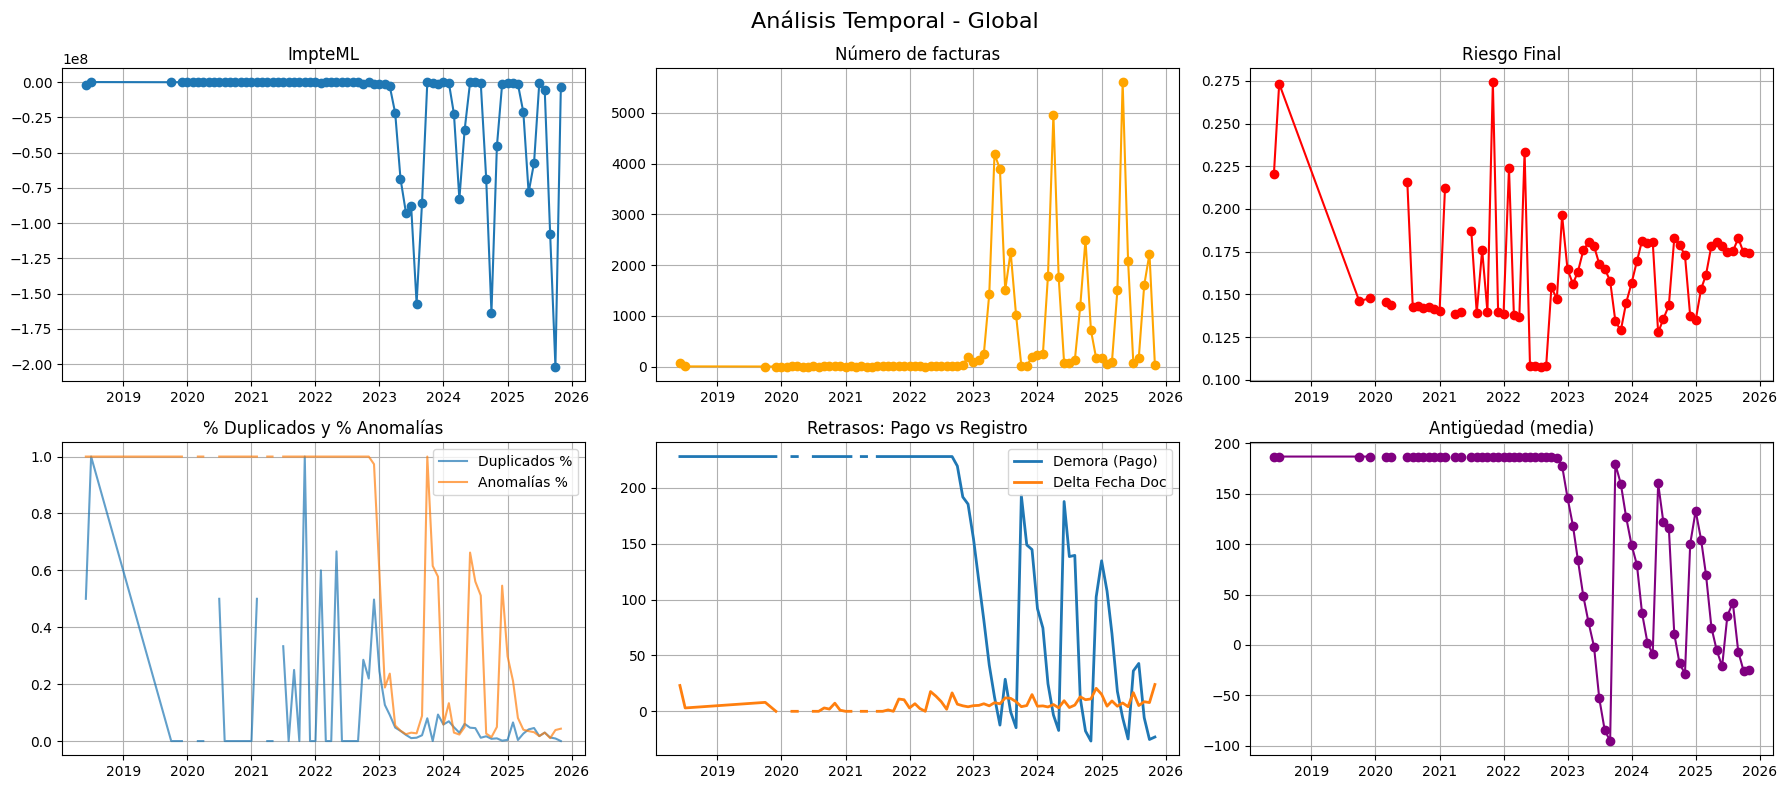

In [31]:
# CELDA 19. ANÁLISIS EXPLORATORIO GLOBAL

df_r = df_region_mes.copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle("Análisis Temporal - Global", fontsize=16)

# 1. ImpteML
axes[0,0].plot(df_r["periodo_dt"], df_r["ImpteML"], marker="o")
axes[0,0].set_title("ImpteML")
axes[0,0].grid(True)

# 2. Nº facturas
axes[0,1].plot(df_r["periodo_dt"], df_r["n_facturas"], marker="o", color="orange")
axes[0,1].set_title("Número de facturas")
axes[0,1].grid(True)

# 3. Riesgo Final
axes[0,2].plot(df_r["periodo_dt"], df_r["Riesgo_final"], marker="o", color="red")
axes[0,2].set_title("Riesgo Final")
axes[0,2].grid(True)

# 4. % duplicados y anomalías
axes[1,0].plot(df_r["periodo_dt"], df_r["pct_duplicados"], label="Duplicados %", alpha=0.7)
axes[1,0].plot(df_r["periodo_dt"], df_r["pct_anomalias"], label="Anomalías %", alpha=0.7)
axes[1,0].set_title("% Duplicados y % Anomalías")
axes[1,0].legend()
axes[1,0].grid(True)

# 5. Retrasos
axes[1,1].plot(df_r["periodo_dt"], df_r["Demora"], label="Demora (Pago)", linewidth=2)
axes[1,1].plot(df_r["periodo_dt"], df_r["Delta_fecha_doc"], label="Delta Fecha Doc", linewidth=2)
axes[1,1].set_title("Retrasos: Pago vs Registro")
axes[1,1].legend()
axes[1,1].grid(True)

# 6. Antigüedad
axes[1,2].plot(df_r["periodo_dt"], df_r["Antigüedad"], marker="o", color="purple")
axes[1,2].set_title("Antigüedad (media)")
axes[1,2].grid(True)

plt.tight_layout()
plt.show()

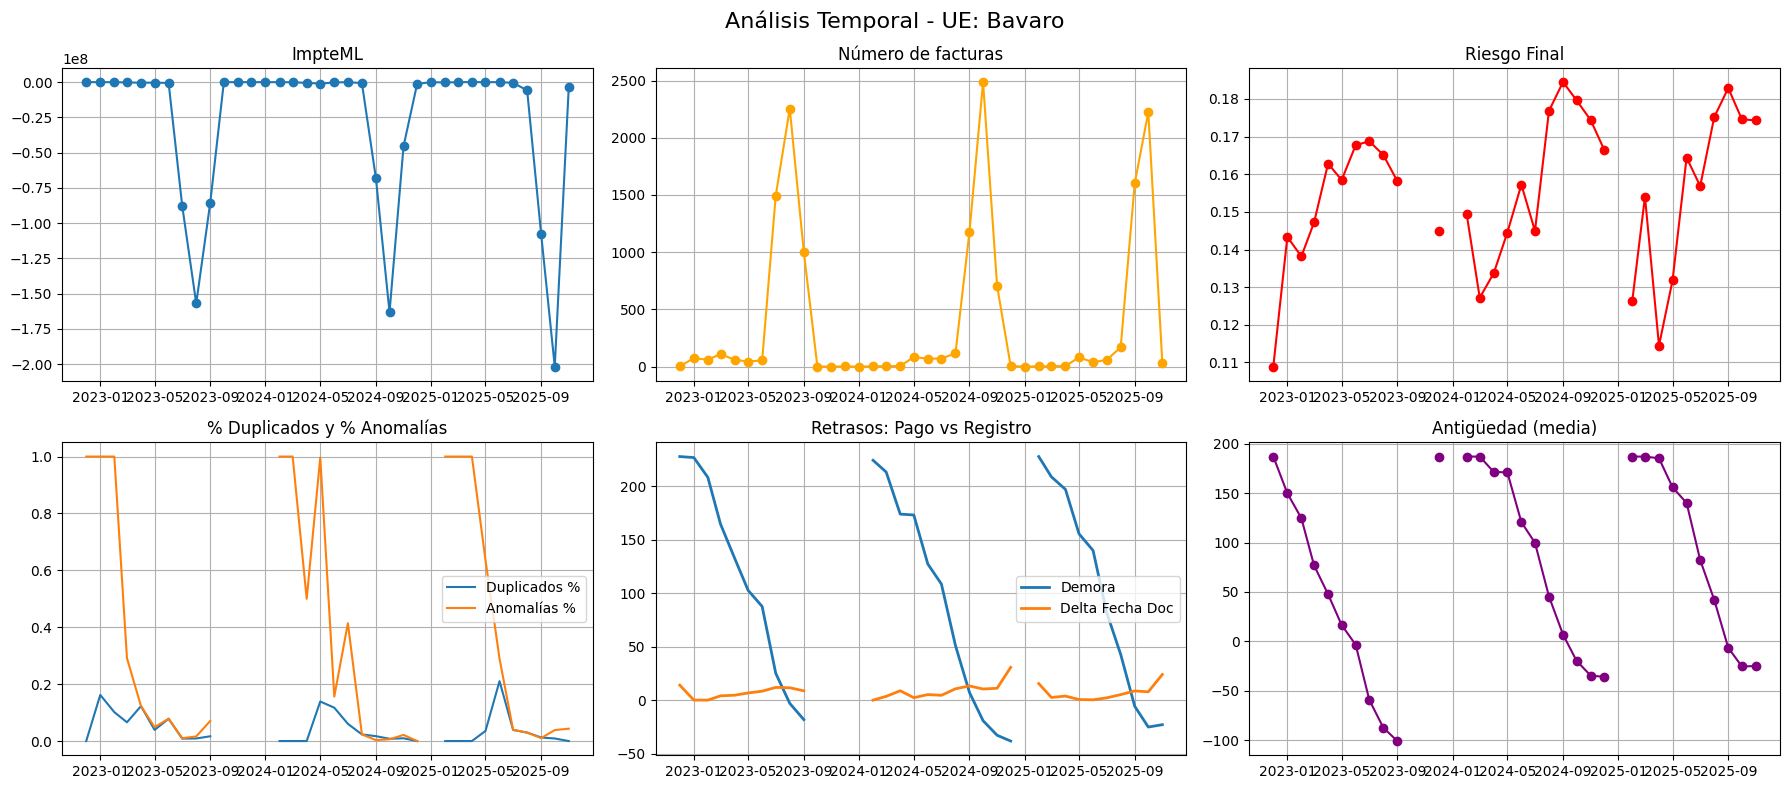

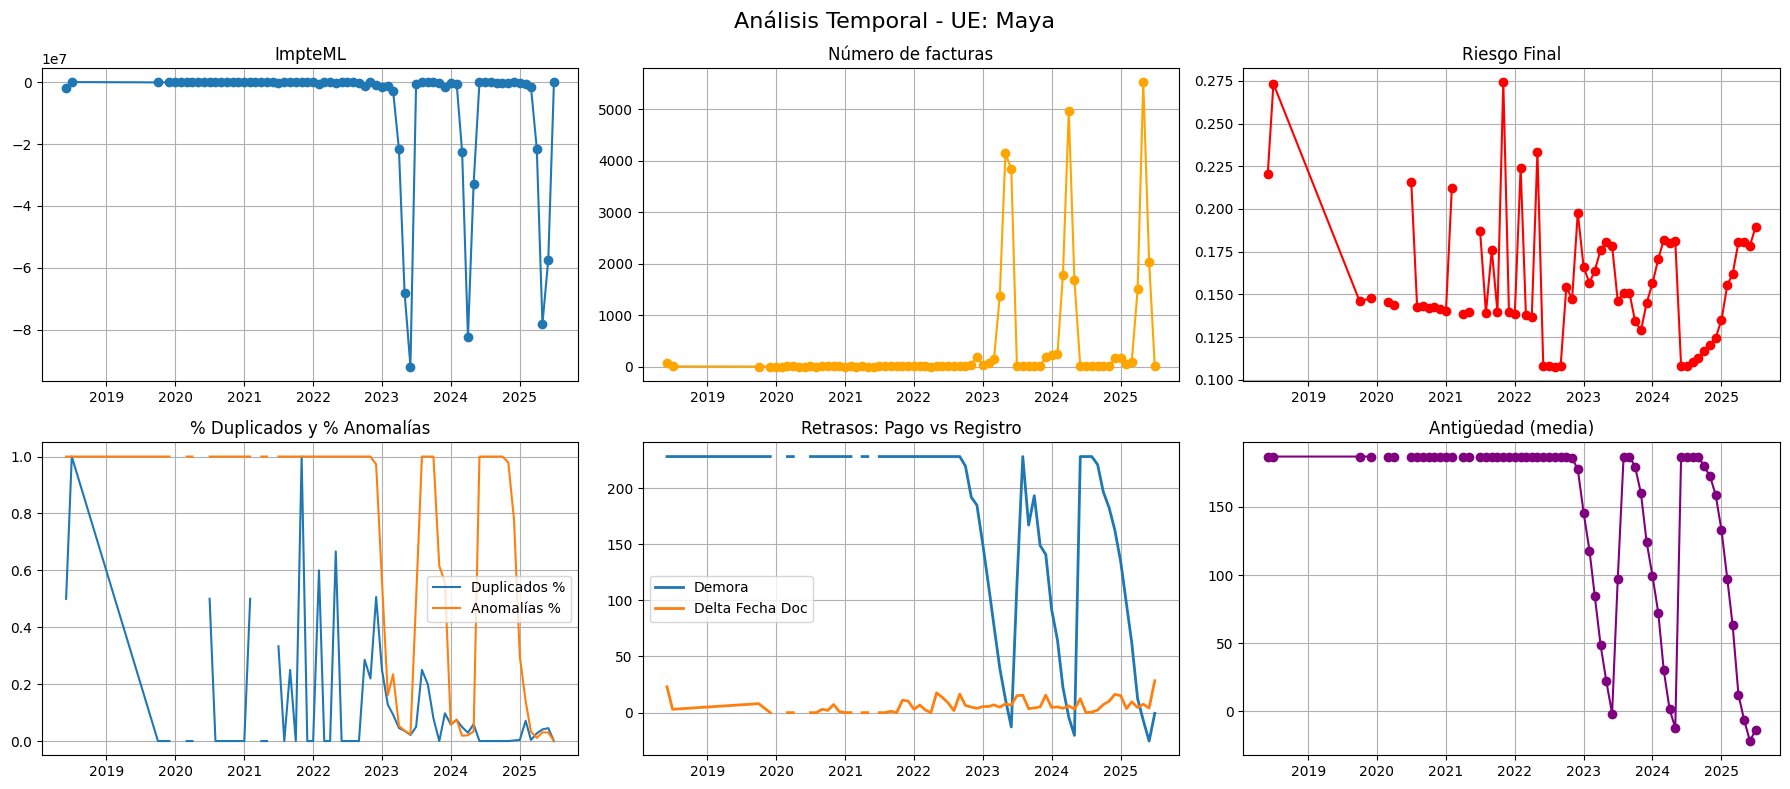

In [32]:
# ============================================================
# CELDA 20. ANÁLISIS EXPLORATORIO POR UE
# ============================================================

ues = df_ue_mes["UE"].dropna().unique()

for ue in ues:
    df_temp = df_ue_mes[df_ue_mes["UE"] == ue]

    fig, axes = plt.subplots(2, 3, figsize=(18, 8))
    fig.suptitle(f"Análisis Temporal - UE: {ue}", fontsize=16)

    axes[0,0].plot(df_temp["periodo_dt"], df_temp["ImpteML"], marker="o")
    axes[0,0].set_title("ImpteML")
    axes[0,0].grid(True)

    axes[0,1].plot(df_temp["periodo_dt"], df_temp["n_facturas"], marker="o", color="orange")
    axes[0,1].set_title("Número de facturas")
    axes[0,1].grid(True)

    axes[0,2].plot(df_temp["periodo_dt"], df_temp["Riesgo_final"], marker="o", color="red")
    axes[0,2].set_title("Riesgo Final")
    axes[0,2].grid(True)

    axes[1,0].plot(df_temp["periodo_dt"], df_temp["pct_duplicados"], label="Duplicados %")
    axes[1,0].plot(df_temp["periodo_dt"], df_temp["pct_anomalias"], label="Anomalías %")
    axes[1,0].set_title("% Duplicados y % Anomalías")
    axes[1,0].legend()
    axes[1,0].grid(True)

    axes[1,1].plot(df_temp["periodo_dt"], df_temp["Demora"], label="Demora", linewidth=2)
    axes[1,1].plot(df_temp["periodo_dt"], df_temp["Delta_fecha_doc"], label="Delta Fecha Doc", linewidth=2)
    axes[1,1].set_title("Retrasos: Pago vs Registro")
    axes[1,1].legend()
    axes[1,1].grid(True)

    axes[1,2].plot(df_temp["periodo_dt"], df_temp["Antigüedad"], marker="o", color="purple")
    axes[1,2].set_title("Antigüedad (media)")
    axes[1,2].grid(True)

    plt.tight_layout()
    plt.show()


UE: Bavaro


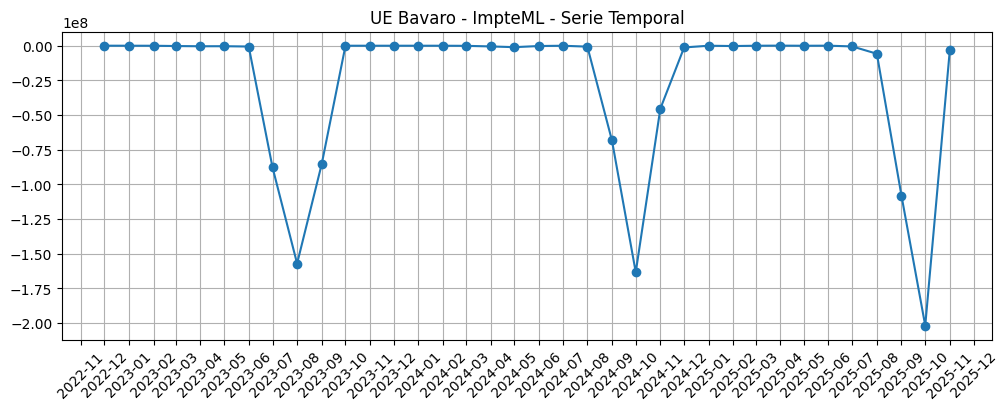

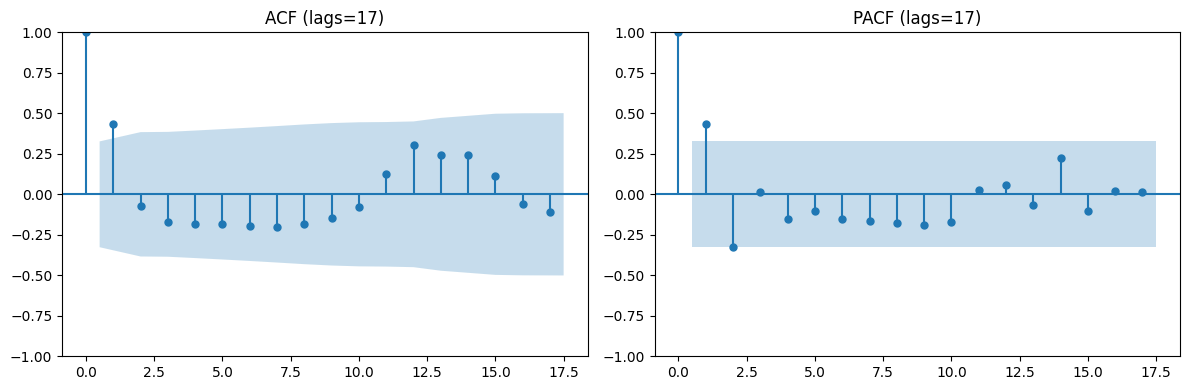

c:\Users\IrenePalomaresCastro\Downloads\SAIH_IMPORT_analisis\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


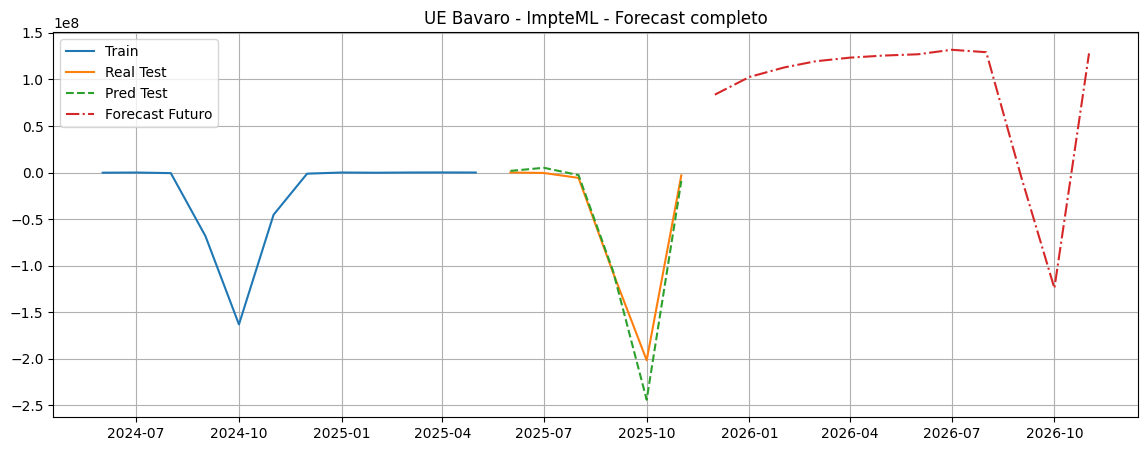

{'adf_stat': np.float64(-4.9269551897152315),
 'pvalue': np.float64(3.089714705281139e-05),
 'estacionaria': np.True_,
 'modelo_seleccionado': 'SARIMAX_auto',
 'razon_modelo': 'Serie estacionaria + larga'}

,MAE,RMSE,MAPE
0,1.006896e+07,1.771601e+07,12.307847



UE: Maya


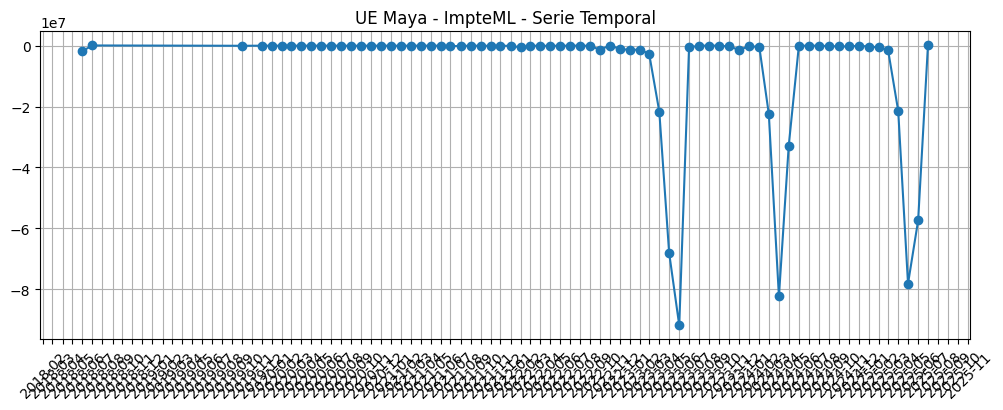

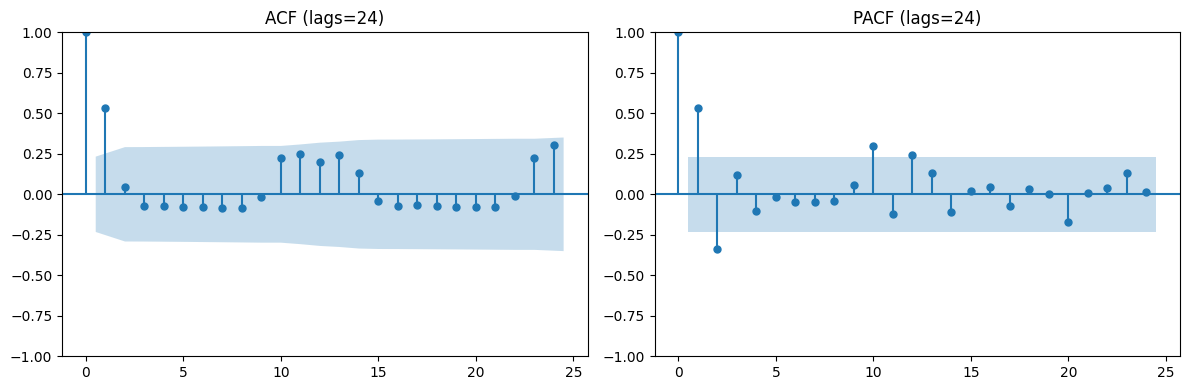

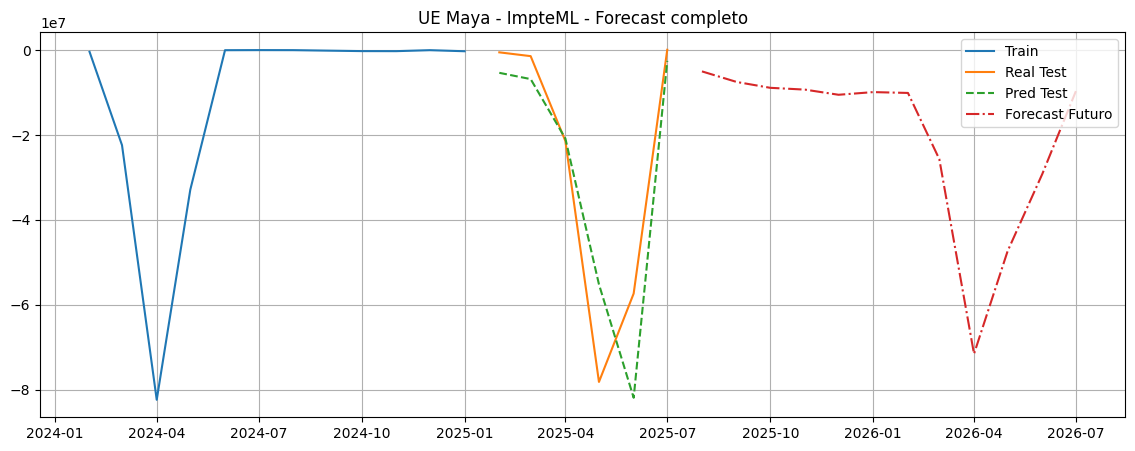

{'adf_stat': np.float64(-5.822411587901069),
 'pvalue': np.float64(4.1533082401368697e-07),
 'estacionaria': np.True_,
 'modelo_seleccionado': 'SARIMAX_auto',
 'razon_modelo': 'Serie estacionaria + larga'}

,MAE,RMSE,MAPE
0,1.016652e+07,1.409621e+07,8.179144


In [33]:
# CELDA 21. DIAGNOSTICO
# FORECAST GENERAL POR UE

for ue in df_ue_mes["UE"].dropna().unique():
    print(f"\nUE: {ue}")

    df_temp = df_ue_mes[df_ue_mes["UE"] == ue]

    modelo, eval_metrics, diagnostico, pred, future = pipeline_forecast_general(
        df_temp,
        "periodo_dt",
        "ImpteML",
        titulo=f"UE {ue} - ImpteML",
        plot_diagnostico=True,
        plot_forecast=True
    )

    display(diagnostico)
    display(eval_metrics)

c:\Users\IrenePalomaresCastro\Downloads\SAIH_IMPORT_analisis\TFG\ml.py:1586: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_res["pct_duplicados"].replace([np.inf, -np.inf], 0, inplace=True)
c:\Users\IrenePalomaresCastro\Downloads\SAIH_IMPORT_analisis\TFG\ml.py:1587: ChainedAssignmentError: A value is being set on a copy of a DataFr


Predicciones finales

UE: GLOBAL


,nivel,UE,periodo_dt,Antigüedad_forecast,Delta_fecha_doc_forecast,Demora_forecast,ImpteML_forecast,n_facturas_forecast,pct_anomalias_forecast,pct_duplicados_forecast,Riesgo_final_rf_forecast
0,GLOBAL,GLOBAL,2025-12-01,51.662625,17.576251,45.979176,67917513.87306,396.779016,0.211235,-0.06245,0.147548
1,GLOBAL,GLOBAL,2026-01-01,55.221667,10.396494,46.084627,47262500.319235,564.450538,0.038117,-0.076268,0.155053
2,GLOBAL,GLOBAL,2026-02-01,39.677665,11.090776,28.73483,56912400.834046,648.827499,-0.051367,0.159769,0.164192
3,GLOBAL,GLOBAL,2026-03-01,10.646828,10.294411,3.729794,51794321.857794,1938.234717,-0.064756,-0.098757,0.157275
4,GLOBAL,GLOBAL,2026-04-01,1.59762,8.940185,-8.240477,42176963.501178,4752.580379,-0.091726,-0.124558,0.156774
5,GLOBAL,GLOBAL,2026-05-01,-4.068361,13.430143,-18.752534,8267709.174979,2860.928512,-0.091838,0.060106,0.165267
6,GLOBAL,GLOBAL,2026-06-01,-22.48116,13.535689,-42.586928,20858389.087403,1104.044552,-0.186473,-0.041501,0.155676
7,GLOBAL,GLOBAL,2026-07-01,-28.809767,11.254804,-22.552946,53568778.892352,694.364858,-0.18911,0.076434,0.162872
8,GLOBAL,GLOBAL,2026-08-01,-29.960262,10.759432,-14.950211,50342584.904677,805.295131,-0.123304,-0.139849,0.155187
9,GLOBAL,GLOBAL,2026-09-01,-50.852292,15.684316,-37.152965,-9611757.295856,1721.014694,-0.139307,-0.103911,0.166692


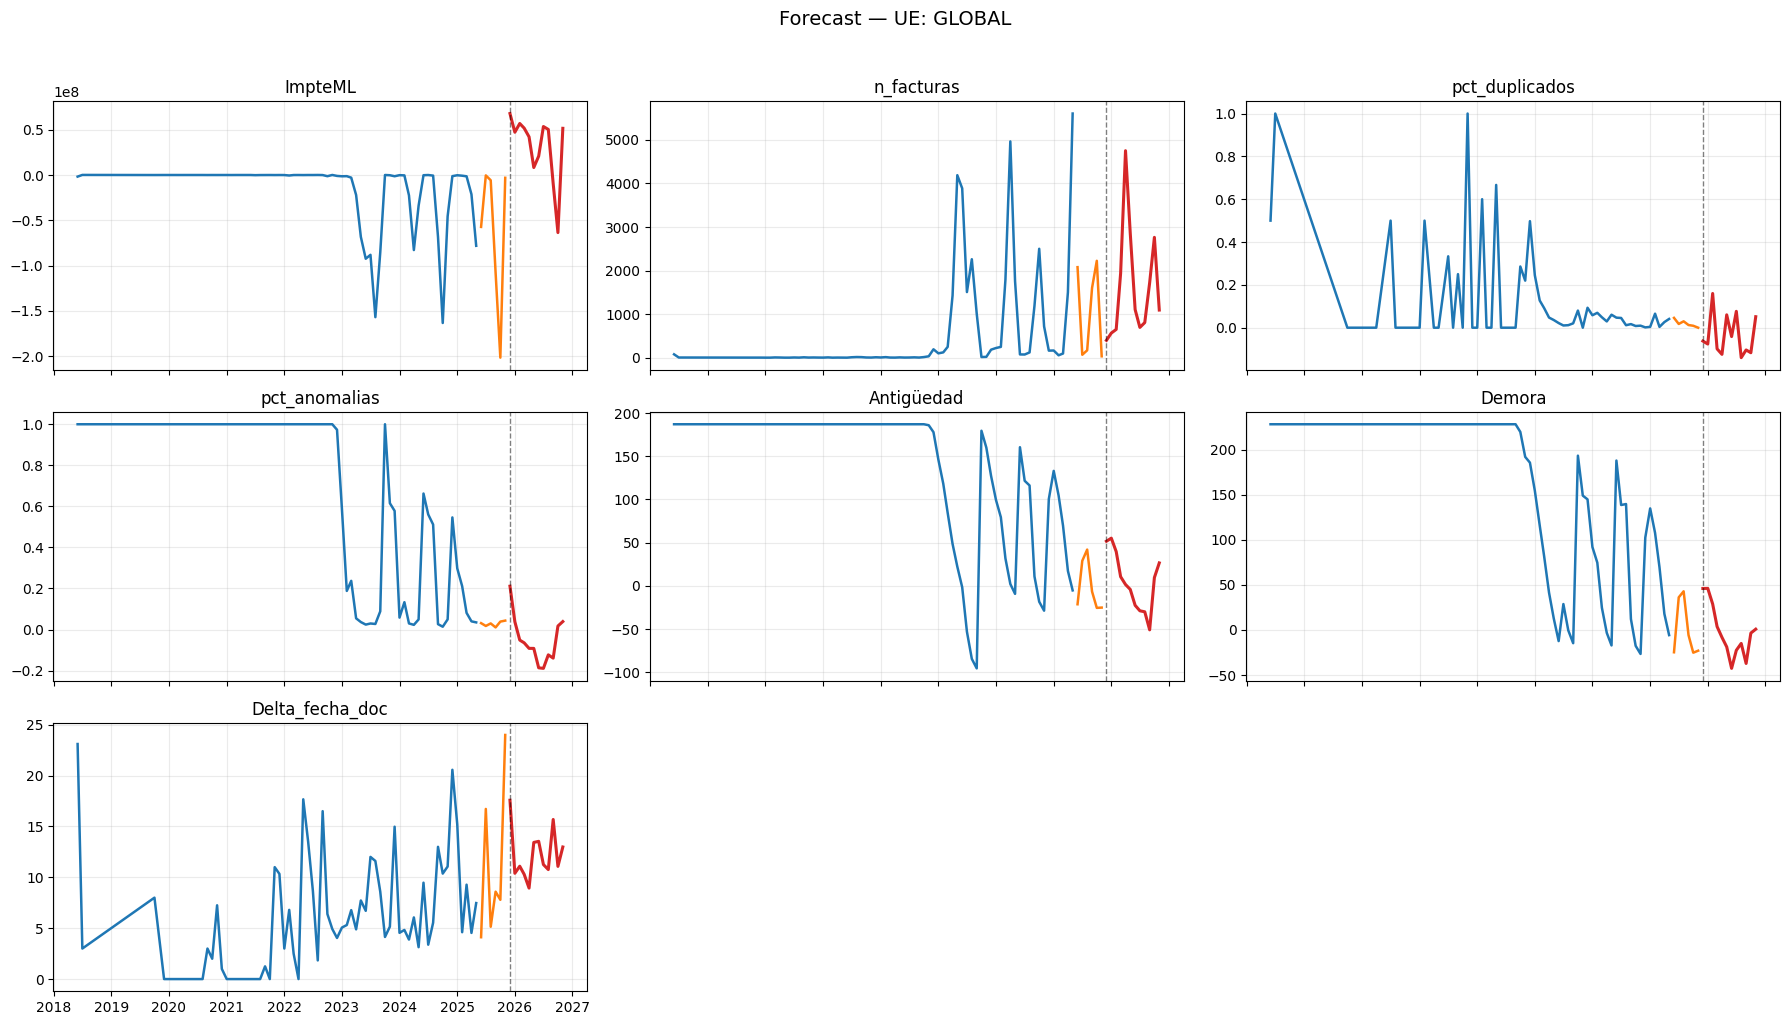


UE: Bavaro


,nivel,UE,periodo_dt,Antigüedad_forecast,Delta_fecha_doc_forecast,Demora_forecast,ImpteML_forecast,n_facturas_forecast,pct_anomalias_forecast,pct_duplicados_forecast,Riesgo_final_rf_forecast
12,UE,Bavaro,2025-12-01,47.02585,21.192132,38.27143,83658222.737426,46.328509,0.048935,-0.000324,0.164905
13,UE,Bavaro,2026-01-01,212.352475,-12.068533,153.443782,102692603.716793,-53.214155,0.044928,-0.010063,0.156345
14,UE,Bavaro,2026-02-01,789.682443,-7.369925,604.659424,112874142.472137,-37.090739,1.030357,-0.010063,0.124667
15,UE,Bavaro,2026-03-01,1376.148791,5.497921,888.871844,119509106.479331,-38.651183,1.031735,-0.010063,0.119973
16,UE,Bavaro,2026-04-01,2454.17248,12.514773,1337.970127,123452653.242917,-35.918194,1.031077,-0.010063,0.115109
17,UE,Bavaro,2026-05-01,4416.918036,26.783729,2014.604875,125671070.390527,38.467065,0.643716,0.025492,0.116795
18,UE,Bavaro,2026-06-01,8061.354614,12.479488,3123.737441,127072962.494125,-0.580128,0.447112,0.200463,0.116522
19,UE,Bavaro,2026-07-01,14722.188415,17.099269,4803.043544,131899771.639269,30.767111,0.091816,0.029152,0.151909
20,UE,Bavaro,2026-08-01,27044.792949,11.407299,7456.559722,129288847.118359,141.073777,0.129371,0.019683,0.150531
21,UE,Bavaro,2026-09-01,49725.342843,20.57873,11573.863857,-3516419.182778,1518.302204,0.044105,0.002389,0.159731


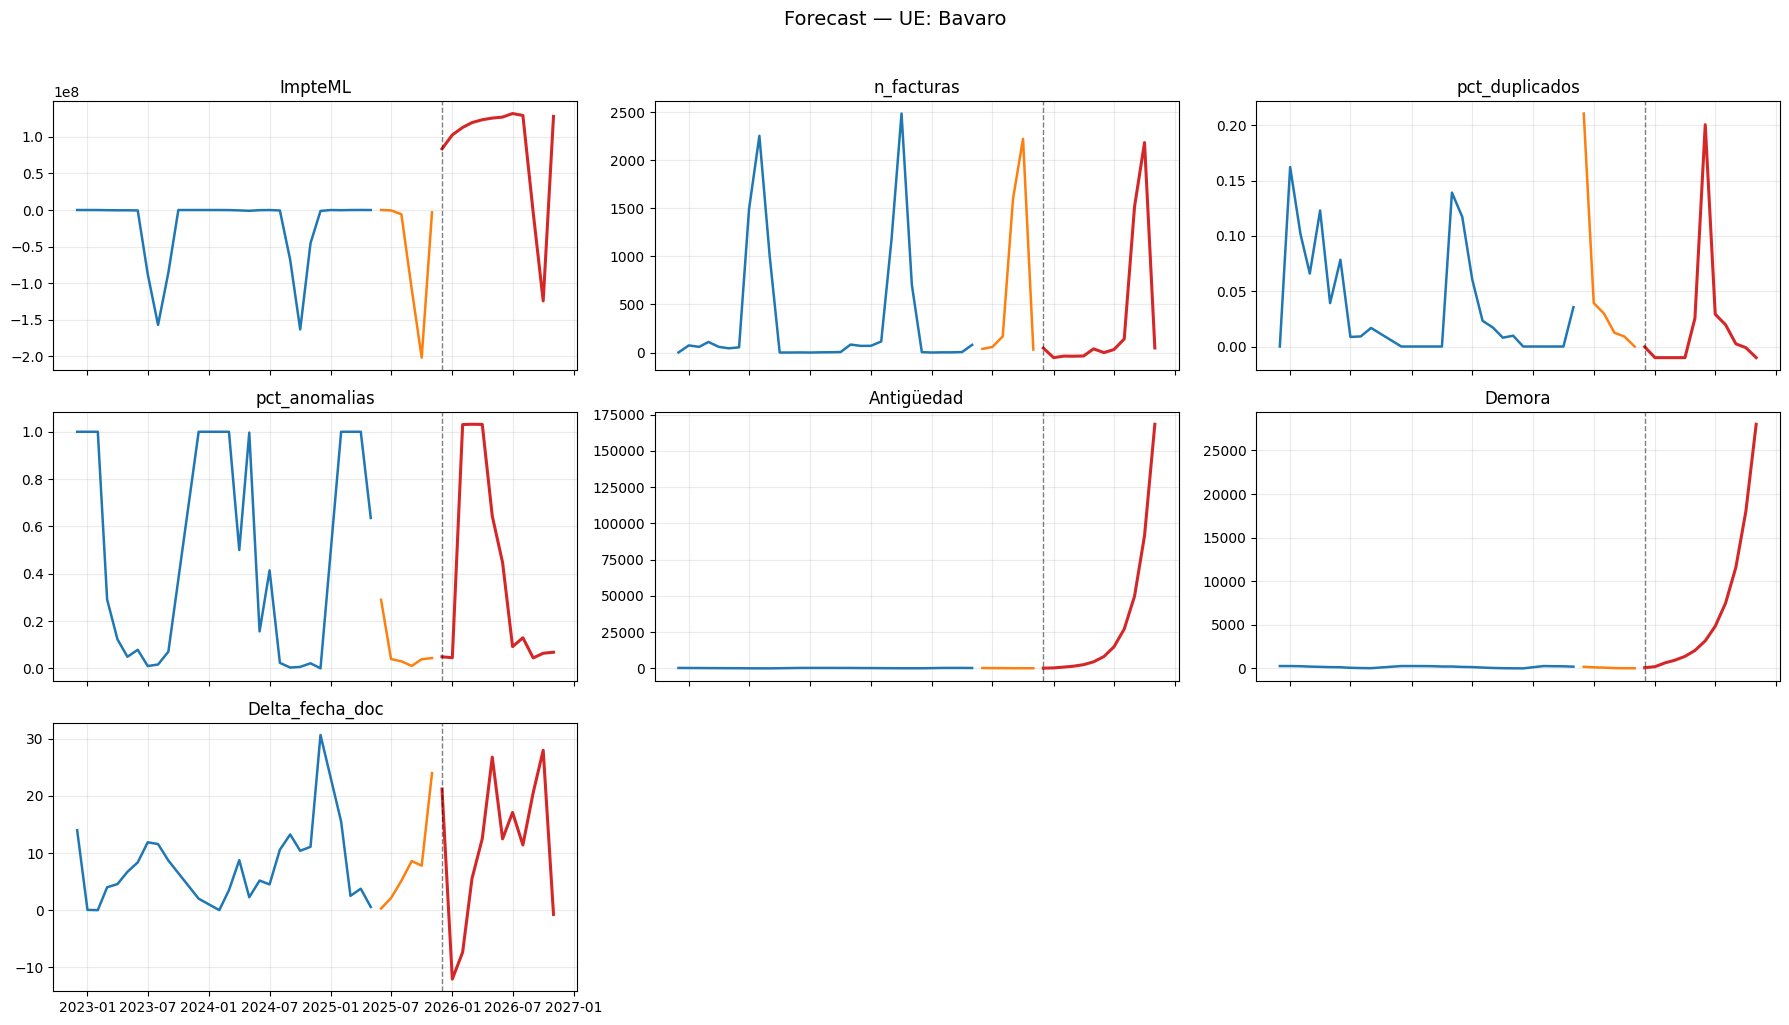


UE: Maya


,nivel,UE,periodo_dt,Antigüedad_forecast,Delta_fecha_doc_forecast,Demora_forecast,ImpteML_forecast,n_facturas_forecast,pct_anomalias_forecast,pct_duplicados_forecast,Riesgo_final_rf_forecast
24,UE,Maya,2025-08-01,117.344844,15.947687,133.209685,-5019903.375417,201.039288,0.581303,-0.100819,0.132217
25,UE,Maya,2025-09-01,117.811468,11.78758,122.858833,-7513578.84254,298.025612,0.583165,-0.055338,0.134666
26,UE,Maya,2025-10-01,107.857206,7.858718,110.355418,-8892075.291433,348.788579,0.533809,-0.098486,0.138641
27,UE,Maya,2025-11-01,110.820989,9.943527,105.343594,-9316208.656394,374.353878,0.52018,0.105708,0.159911
28,UE,Maya,2025-12-01,97.33457,14.342932,93.669606,-10530379.530572,546.840682,0.431879,-0.072155,0.14163
29,UE,Maya,2026-01-01,85.563111,8.085297,78.731953,-9901210.972032,579.883604,0.19687,-0.088902,0.151493
30,UE,Maya,2026-02-01,67.689123,9.726634,58.633107,-10099639.480468,599.768419,0.085886,0.146928,0.166711
31,UE,Maya,2026-03-01,50.836901,8.664251,41.906547,-25706211.594317,1998.938378,0.12207,-0.10368,0.164274
32,UE,Maya,2026-04-01,35.000377,8.516572,27.235075,-71601118.650913,4991.357013,0.086841,-0.13744,0.167017
33,UE,Maya,2026-05-01,20.698298,10.625099,12.135419,-47384999.386912,2348.998299,0.068002,0.039321,0.179011


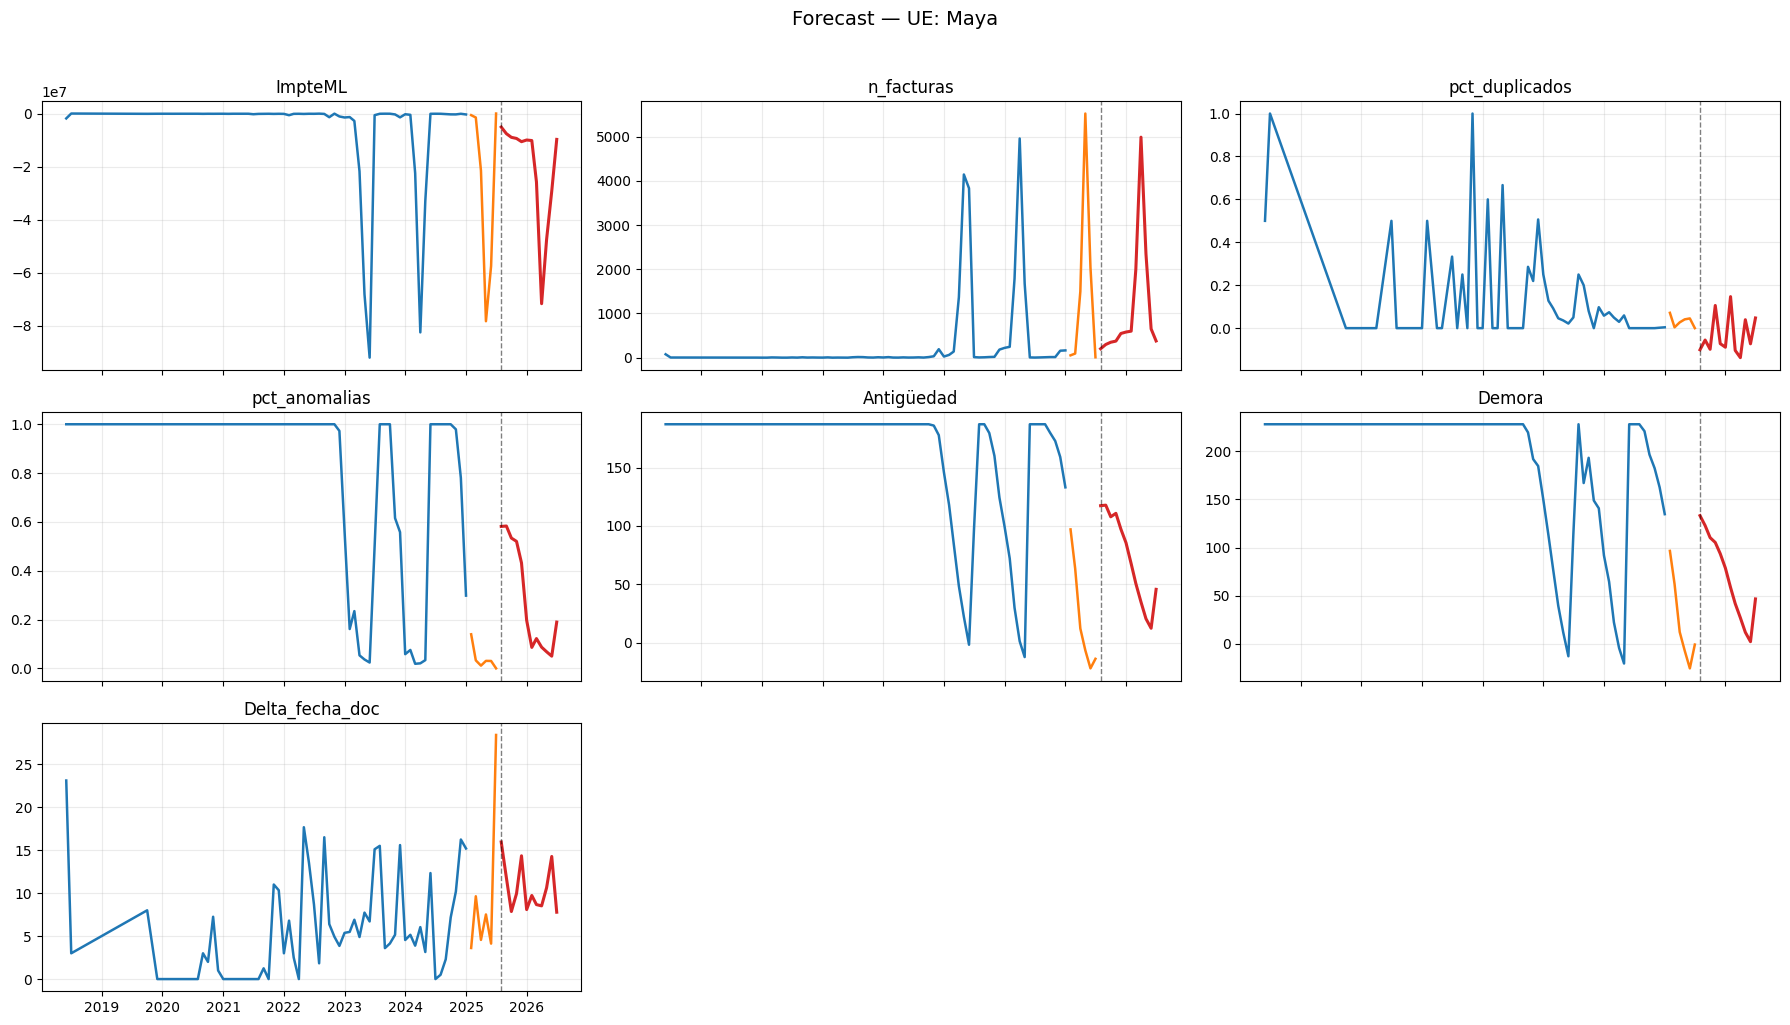

In [34]:
# CELDA 22. FORECAST BATCH DE VARIABLES

df_metricas, df_predicciones, df_final = forecast_batch(
    df_ts,
    steps_test=6,
    steps_future=12,
    plot_diagnostico=False,
    plot_forecast=False
)

vars_7 = [
    "ImpteML", "n_facturas", "pct_duplicados", "pct_anomalias",
    "Antigüedad", "Demora", "Delta_fecha_doc"
]

print("\nPredicciones finales")

for ue in df_final["UE"].dropna().unique():
    print(f"\nUE: {ue}")
    df_ue = df_final[df_final["UE"] == ue]
    display(df_ue)
    plot_panel_train_test_pred(
        df_predicciones,
        ue=ue,
        variables=vars_7,
        steps_test=6,
        ncols=3,
        figsize=(18, 10)
    )

In [35]:
# ============================================================
# CELDA 24. PICOS DE VARIABLES FORECAST
# ============================================================

fecha_col = "periodo_dt"

vars_forecast = [
    "Antigüedad_forecast",
    "Delta_fecha_doc_forecast",
    "Demora_forecast",
    "ImpteML_forecast",
    "n_facturas_forecast",
    "pct_anomalias_forecast",
    "pct_duplicados_forecast",
    "Riesgo_final_rf_forecast"
]

for var in vars_forecast:
    print(f"\nVariable: {var}")
    peaks = (
        df_final.groupby("UE")
                .apply(lambda g: g.loc[g[var].idxmax(), [fecha_col, var]])
                .reset_index()
    )
    display(peaks)


Variable: Antigüedad_forecast


,UE,periodo_dt,Antigüedad_forecast
0,Bavaro,2026-11-01,168462.393634
1,GLOBAL,2026-01-01,55.221667
2,Maya,2025-09-01,117.811468



Variable: Delta_fecha_doc_forecast


,UE,periodo_dt,Delta_fecha_doc_forecast
0,Bavaro,2026-10-01,27.990827
1,GLOBAL,2025-12-01,17.576251
2,Maya,2025-08-01,15.947687



Variable: Demora_forecast


...

,UE,periodo_dt,pct_anomalias_forecast
0,Bavaro,2026-03-01,1.031735
1,GLOBAL,2025-12-01,0.211235
2,Maya,2025-09-01,0.583165



Variable: pct_duplicados_forecast


,UE,periodo_dt,pct_duplicados_forecast
0,Bavaro,2026-06-01,0.200463
1,GLOBAL,2026-02-01,0.159769
2,Maya,2026-02-01,0.146928



Variable: Riesgo_final_rf_forecast


,UE,periodo_dt,Riesgo_final_rf_forecast
0,Bavaro,2025-12-01,0.164905
1,GLOBAL,2026-10-01,0.173158
2,Maya,2026-05-01,0.179011


In [36]:
# ============================================================
# CELDA 25. EXTREMOS ANUALES GLOBALES
# ============================================================

variables = [
    "ImpteML", "n_facturas", "Riesgo_final",
    "pct_duplicados", "pct_anomalias",
    "Antigüedad", "Demora", "Delta_fecha_doc"
]

dfs = []
for var in variables:
    df_tmp = extremos_anuales(df_r, "periodo_dt", var)
    df_tmp = df_tmp.set_index("año")
    df_tmp = df_tmp.add_prefix(f"{var}_")
    dfs.append(df_tmp)

df_horizontal = pd.concat(dfs, axis=1)

display(df_horizontal)

,ImpteML_min,ImpteML_max,n_facturas_min,n_facturas_max,Riesgo_final_min,Riesgo_final_max,pct_duplicados_min,pct_duplicados_max,pct_anomalias_min,pct_anomalias_max,Antigüedad_min,Antigüedad_max,Demora_min,Demora_max,Delta_fecha_doc_min,Delta_fecha_doc_max
año,,,,,,,,,,,,,,,,
2018,06,07,07,06,06,07,06,07,06,06,06,06,06,06,07,06
2019,10,12,10,10,10,12,10,10,10,10,10,10,10,10,12,10
2020,09,01,01,09,12,07,03,07,03,03,03,03,03,03,03,11
2021,07,03,03,08,04,11,01,11,01,01,01,01,01,01,01,11
2022,10,08,04,12,08,05,01,05,12,01,12,01,12,01,04,05
2023,08,10,10,05,11,05,11,01,06,10,09,10,09,10,10,12
2024,10,07,07,04,06,09,12,02,10,06,11,06,11,06,05,12
2025,10,01,11,05,01,09,11,02,09,01,10,01,10,01,06,11


In [37]:
# ============================================================
# CELDA 26. EXTREMOS ANUALES POR UE
# ============================================================

for ue in df_ue_mes["UE"].dropna().unique():
    print(f"\nUE: {ue}")
    df_temp = df_ue_mes[df_ue_mes["UE"] == ue]

    variables = [
        "ImpteML", "n_facturas", "Riesgo_final",
        "pct_duplicados", "pct_anomalias",
        "Antigüedad", "Demora", "Delta_fecha_doc"
    ]

    dfs = []
    for var in variables:
        df_tmp = extremos_anuales(df_temp, "periodo_dt", var)
        df_tmp = df_tmp.set_index("año")
        df_tmp = df_tmp.add_prefix(f"{var}_")
        dfs.append(df_tmp)

    df_horizontal = pd.concat(dfs, axis=1)
    display(df_horizontal)


UE: Bavaro


,ImpteML_min,ImpteML_max,n_facturas_min,n_facturas_max,Riesgo_final_min,Riesgo_final_max,pct_duplicados_min,pct_duplicados_max,pct_anomalias_min,pct_anomalias_max,Antigüedad_min,Antigüedad_max,Demora_min,Demora_max,Delta_fecha_doc_min,Delta_fecha_doc_max
año,,,,,,,,,,,,,,,,
2022,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12
2023,08,10,10,08,02,07,12,01,07,01,09,12,09,12,02,07
2024,10,01,01,10,03,09,02,05,12,02,12,02,12,02,02,12
2025,10,04,01,10,04,09,02,06,09,02,10,02,10,02,06,11



UE: Maya


,ImpteML_min,ImpteML_max,n_facturas_min,n_facturas_max,Riesgo_final_min,Riesgo_final_max,pct_duplicados_min,pct_duplicados_max,pct_anomalias_min,pct_anomalias_max,Antigüedad_min,Antigüedad_max,Demora_min,Demora_max,Delta_fecha_doc_min,Delta_fecha_doc_max
año,,,,,,,,,,,,,,,,
2018,06,07,07,06,06,07,06,07,06,06,06,06,06,06,07,06
2019,10,12,10,10,10,12,10,10,10,10,10,10,10,10,12,10
2020,09,01,01,09,12,07,03,07,03,03,03,03,03,03,03,11
2021,07,03,03,08,04,11,01,11,01,01,01,01,01,01,01,11
2022,10,08,04,12,08,05,01,05,12,01,12,01,12,01,04,05
2023,06,09,08,05,11,05,11,01,06,08,06,08,06,08,09,12
2024,04,07,07,04,07,03,06,02,03,06,05,06,05,06,07,12
2025,05,07,07,05,01,07,07,02,07,01,06,01,06,01,02,07


In [38]:
# ============================================================
# CELDA 27. EXPORT FINAL
# ============================================================

excel_ml(df, output_path="Maya_Bavaro_ml.xlsx")
print("Excel final generado: Maya_Bavaro_ml.xlsx")

42 partidas detectadas como anticipos (407)
0 partidas detectadas como retenciones (40010001)
[Duplicados_UE] sequence item 1: expected str instance, float found


c:\Users\IrenePalomaresCastro\Downloads\SAIH_IMPORT_analisis\TFG\ml.py:1586: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_res["pct_duplicados"].replace([np.inf, -np.inf], 0, inplace=True)
c:\Users\IrenePalomaresCastro\Downloads\SAIH_IMPORT_analisis\TFG\ml.py:1587: ChainedAssignmentError: A value is being set on a copy of a DataFr

Excel final generado: Maya_Bavaro_ml.xlsx
